This notebook reproduces Fig 1 of paper Normative modeling of neuroimaging data using generalized additive models of location scale and shape (https://www.biorxiv.org/content/10.1101/2021.06.14.448106v1) in python instead or R, using the package PCNtoolkit (https://github.com/amarquand/PCNtoolkit/tree/77341474f42d182315ec151df03d1fbbfa3d1dff). The package implements Bayesian Hierarchical Regression with MCMC (NUT sampler) for generalized additive models of location scale and shape (GAMLSS). 

We also do model comparison using bayesian criteria.

In [1]:
import os
import pandas as pd # 1.4.2
from IPython.display import display
import arviz as az #there can be conflict between arviz and pcntoolkit versions
import pcntoolkit as ptk  
import numpy as np # 1.22.3 
import pickle
from matplotlib import pyplot as plt # 3.5.1 
import seaborn as sns # 0.11.2
sns.set(style='whitegrid')
import scipy.stats as sst 
import pymc as pm 
from itertools import product, combinations
from scipy.stats import norm
from scipy.special import logsumexp
import graphviz
graphviz.set_jupyter_format('png')
from copy import deepcopy

'svg'

In [2]:
processing_dir = os.getcwd()

In [3]:
shasho2_object = ptk.model.SHASH.SHASHo2RV() 

In [4]:
#dir(shasho2_object)

It seems like to sample from our variable, the syntax is: shashobject.rng_fn(rng, mu, sigma, nu, tau))
where rng = np.random.default_rng() for example.
It seems consistent with the tests below:

We check if we are drawing from a SHASH distribution: 
* shash(0, 1, 0, 1) is supposed to be the same as normal(0, 1)

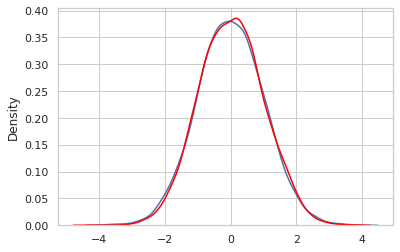

In [5]:
shash_draws = []
normal_draws = []
for i in range(5000) :
    shash_draws.append(shasho2_object.rng_fn(np.random.default_rng(), 0, 1, 0, 1))
    normal_draws.append(np.random.normal(0, 1))
sns.kdeplot(shash_draws)
sns.kdeplot(normal_draws, color='red') ;

* Comparison with plot given in https://statisticaloddsandends.wordpress.com/2019/04/15/the-sinh-arcsinh-normal-distribution/ looks good

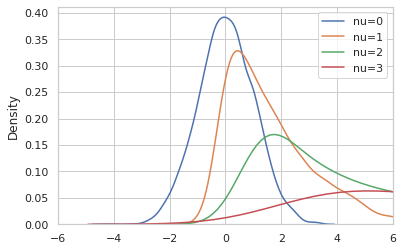

In [6]:
shash_draws = np.empty((4, 5000))
normal_draws = []
for nu in [0, 1, 2, 3] :
    for i in range(5000) :
        shash_draws[nu, i] = shasho2_object.rng_fn(np.random.default_rng(), 0, 1, nu, 1)
        
    sns.kdeplot(shash_draws[nu, :], label='nu='+str(nu))
plt.xlim([-6, 6])
plt.legend();

Generate dataset that is used in the paper:

In [7]:
n_pts = 1000
x = np.linspace(0, 100, n_pts)
sigmas = 0.5 + 1.5 * np.linspace(-1, 1, n_pts)**2 #we prepare for heterogenous noise

#shash draws
rng = np.random.default_rng(seed=0)
shash_draws = []
for sigma in sigmas :
    shash_draws.append(shasho2_object.rng_fn(rng, 0, sigma, -1.5, 1))
shash_draws = np.array(shash_draws)

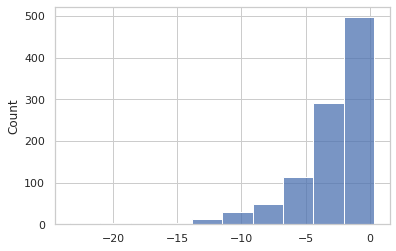

In [8]:
#we plot the SHASHo2 draws:
sns.histplot(shash_draws, bins=10) ;
#The histogram is consistent with the one from rSHASHo2(n = n_pts, sigma = sigmas, nu=-1.5, tau=1) in R

In [9]:
y = 50 + 0.15*x - 0.003*(x**2) + shash_draws

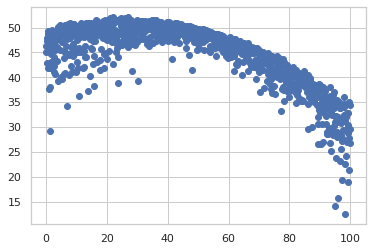

In [10]:
plt.plot(x, y, 'o') ;

In [11]:
#true mean is:
mu_true = 50 + 0.15*x - 0.003*(x**2)

In [12]:
data = pd.DataFrame({'x':x, 'y':y})
data.head()

,x,y
0,0.0000,46.299451
1,0.1001,45.112649
2,0.2002,47.998222
3,0.3003,46.290412
4,0.4004,42.796245


In [13]:
#save data
with open('x.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(x), file)
with open('y.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(y), file)

In [14]:
#we have to save the response and covariate data into files to provide them to the package
respfile = os.path.join(processing_dir, 'y.pkl')
covfile = os.path.join(processing_dir, 'x.pkl')

#in this example we don't specify a batch effects file 
#we also don't use test data

output_path = os.path.join(processing_dir, 'Models/') # output path, where the models and inference will be written
if not os.path.isdir(output_path):
    os.mkdir(output_path)
    
log_dir = os.path.join(processing_dir, 'log/') # log path, where the log is written
if not os.path.isdir(log_dir):
    os.mkdir(log_dir)

## 1. A. Simple linear regression:

$$ y \sim N(\mu,\sigma), \,\, \mu = \beta x$$

with homoscedastic noise $\sigma$ that does not vary depending on $x$.

In [15]:
 outputsuffix = '_linear-homo-estimate'  

In [16]:
likelihood = 'Normal'
model_type = 'linear'

linear_mu = 'True' #trend is regressed on x
linear_sigma = 'False' #noise is not regressed on x

#no random effects on the components of mu and sigma:
random_intercept_mu = 'False'
random_slope_mu = 'False'
random_intercept_sigma = 'False'
random_slope_sigma = 'False'

centered_intercept_mu = 'True'

#for faster computation:
inscaler_type='standardize'
outscaler_type='standardize'
inscaler = ptk.util.utils.scaler(inscaler_type)
x_standardized = inscaler.fit_transform(x)
outscaler = ptk.util.utils.scaler(outscaler_type)
y_standardized = outscaler.fit_transform(y)

In [253]:
n_mcmc_samples = 1500
n_tuning_samples = 500
n_chains = 4
n_cores = 16
target_accept = 0.99

In [294]:
alg='hbr' #hierarchical bayesian regression
saveoutput='True'
savemodel='True'
binary='True'

In [295]:
ptk.normative.fit(covfile=covfile,
                  respfile=respfile,
                  log_path=log_dir,
                  saveoutput=saveoutput,
                  output_path=output_path, 
                  savemodel=savemodel,
                  binary=binary,
                  outputsuffix=outputsuffix,
                  alg=alg,
                  n_samples=n_mcmc_samples,
                  n_tuning=n_tuning_samples,
                  n_chains=n_chains,
                  cores=n_cores,
                  target_accept=target_accept,
                  inscaler=inscaler_type,
                  outscaler=outscaler_type,
                  
                  likelihood=likelihood,
                  model_type=model_type,
                  linear_mu = linear_mu,
                  linear_sigma = linear_sigma,
                  random_intercept_mu = random_intercept_mu,
                  random_slope_mu = random_slope_mu,
                  random_intercept_sigma = random_intercept_sigma,
                  random_slope_sigma = random_slope_sigma,
                  centered_intercept_mu = centered_intercept_mu
                 )


Processing data in /home/tng/Documents/phd/normative modeling/gamlss_normative_paper_with_PCN_HBR/y.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 16 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 6 seconds.
There were 354 divergences after tuning. Increase `target_accept` or reparameterize.


Saving model meta-data...


In [296]:
# Load the model and show the idata (the object that contains the MCMC samples)
model_path = os.path.join(output_path, f'NM_0_0{outputsuffix}.pkl')
nm = pickle.load(open(model_path,'rb'))
nm.hbr.idata.posterior

<xarray.Dataset>
Dimensions:             (chain: 4, draw: 1500, basis_functions: 1,
                         batch_effect_0: 1, datapoints: 1000, empty: 1)
Coordinates:
  * chain               (chain) int64 0 1 2 3
  * draw                (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
  * basis_functions     (basis_functions) int64 0
  * batch_effect_0      (batch_effect_0) int16 0
  * datapoints          (datapoints) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * empty               (empty) int64 0
Data variables:
    slope_mu            (chain, draw, basis_functions) float64 -0.6941 ... -0...
    intercept_mu        (chain, draw) float64 0.02024 0.001603 ... -0.008258
    mu_sigma            (chain, draw) float64 -3.133 -3.729 ... -3.584 -2.717
    sigma               (chain, draw, batch_effect_0) float64 -3.768 ... -3.86
    sigma_sigma         (chain, draw) float64 0.6275 0.7391 ... 0.9777 1.41
    mu_samples          (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-01-10T13:28:27.128237
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              6.173068046569824
    tuning_steps:               500

In [297]:
# Get the MCMC-estimated quantiles
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

zscores = np.arange(-3, 4)[:,np.newaxis]

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 200
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

q = nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores)

Sampling: [y_like]


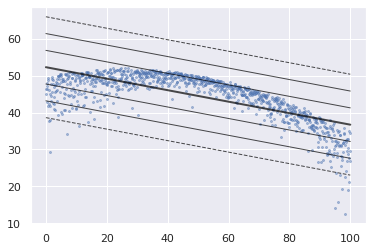

In [298]:
# plot the quantiles
plt.scatter(x, y, s = 4, alpha = 0.4)
for i, v in enumerate(zscores):
    thickness = 1
    linestyle = "-"
    if v == 0:
        thickness = 2
    if abs(v) > 2:
        linestyle = "--"
    plt.plot(inscaler.inverse_transform(synthetic_x), outscaler.inverse_transform(q[i]), linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)

## 2.B. Linear regression, with heteroscedastic noise $\sigma$

$$ y \sim N(\mu,\sigma), \,\, \mu = \beta_{\mu} x, \,\, \sigma = \beta_{sigma} x$$

In [299]:
outputsuffix = '_linear-hetero-estimate' 

In [300]:
likelihood = 'Normal'
model_type = 'linear'

linear_mu = 'True' #trend is regressed on x
linear_sigma = 'True' #noise is also regressed on x

#no random effects on the components of mu and sigma:
random_intercept_mu = 'False'
random_slope_mu = 'False'
random_intercept_sigma = 'False'
random_slope_sigma = 'False'

centered_intercept_mu = 'True'

#for faster computation:
inscaler_type='standardize'
outscaler_type='standardize'
inscaler = ptk.util.utils.scaler(inscaler_type)
x_standardized = inscaler.fit_transform(x)
outscaler = ptk.util.utils.scaler(outscaler_type)
y_standardized = outscaler.fit_transform(y)

In [301]:
n_mcmc_samples = 1500
n_tuning_samples = 500
n_chains = 4
n_cores = 16
target_accept = 0.99

In [302]:
alg='hbr'
saveoutput='True'
savemodel='True'
binary='True'

In [303]:
ptk.normative.fit(covfile=covfile,
                  respfile=respfile,
                  log_path=log_dir,
                  saveoutput=saveoutput,
                  output_path=output_path, 
                  savemodel=savemodel,
                  binary=binary,
                  outputsuffix=outputsuffix,
                  alg=alg,
                  n_samples=n_mcmc_samples,
                  n_tuning=n_tuning_samples,
                  n_chains=n_chains,
                  cores=n_cores,
                  target_accept=target_accept,
                  inscaler=inscaler_type,
                  outscaler=outscaler_type,
                  
                  likelihood=likelihood,
                  model_type=model_type,
                  linear_mu = linear_mu,
                  linear_sigma = linear_sigma,
                  random_intercept_mu = random_intercept_mu,
                  random_slope_mu = random_slope_mu,
                  random_intercept_sigma = random_intercept_sigma,
                  random_slope_sigma = random_slope_sigma,
                  centered_intercept_mu = centered_intercept_mu
                 )


Processing data in /home/tng/Documents/phd/normative modeling/gamlss_normative_paper_with_PCN_HBR/y.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 16 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 4 seconds.


Saving model meta-data...


In [304]:
# Load the model and show the idata (the object that contains the MCMC samples)
model_path = os.path.join(output_path, f'NM_0_0{outputsuffix}.pkl')
nm = pickle.load(open(model_path,'rb'))
nm.hbr.idata.posterior

<xarray.Dataset>
Dimensions:             (chain: 4, draw: 1500, basis_functions: 1,
                         datapoints: 1000, empty: 1)
Coordinates:
  * chain               (chain) int64 0 1 2 3
  * draw                (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
  * basis_functions     (basis_functions) int64 0
  * datapoints          (datapoints) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * empty               (empty) int64 0
Data variables:
    slope_mu            (chain, draw, basis_functions) float64 -0.5744 ... -0...
    intercept_mu        (chain, draw) float64 0.05751 -0.02023 ... 0.01058
    slope_sigma         (chain, draw, basis_functions) float64 0.3614 ... 0.4641
    intercept_sigma     (chain, draw) float64 -3.732 -4.002 ... -3.957 -3.921
    mu_samples          (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-01-10T13:32:12.294872
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              4.221458435058594
    tuning_steps:               500

In [305]:
# Get the MCMC-estimated quantiles
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

zscores = np.arange(-3, 4)[:,np.newaxis]

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 200
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

q = nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores)

Sampling: [y_like]


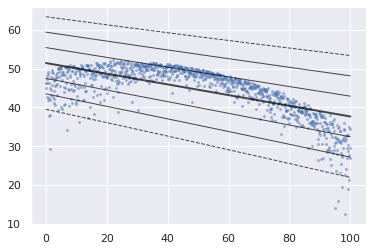

In [306]:
# plot the quantiles
plt.scatter(x, y, s = 4, alpha = 0.4)
for i, v in enumerate(zscores):
    thickness = 1
    linestyle = "-"
    if v == 0:
        thickness = 2
    if abs(v) > 2:
        linestyle = "--"
    plt.plot(inscaler.inverse_transform(synthetic_x), outscaler.inverse_transform(q[i]), linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)

## GAM, homoscedastic noise 

$$y \sim N(\mu, \sigma), \,\, \mu = f(x) $$ 

where $f$ is a smooth function, here a B-spline function.

In [307]:
outputsuffix = '_gam-homo-estimate' 

In [308]:
likelihood = 'Normal'
model_type = 'bspline'

linear_mu = 'True' #trend is regressed on x
linear_sigma = 'False' #noise is not regressed on x

#no random effects on the components of mu and sigma:
random_intercept_mu = 'False'
random_slope_mu = 'False'
random_intercept_sigma = 'False'
random_slope_sigma = 'False'

centered_intercept_mu = 'True'

#for faster computation:
inscaler_type='standardize'
outscaler_type='standardize'
inscaler = ptk.util.utils.scaler(inscaler_type)
x_standardized = inscaler.fit_transform(x)
outscaler = ptk.util.utils.scaler(outscaler_type)
y_standardized = outscaler.fit_transform(y)

In [309]:
n_mcmc_samples = 1500
n_tuning_samples = 500
n_chains = 4
n_cores = 16
target_accept = 0.99

In [310]:
alg='hbr'
saveoutput='True'
savemodel='True'
binary='True'

In [311]:
ptk.normative.fit(covfile=covfile,
                  respfile=respfile,
                  log_path=log_dir,
                  saveoutput=saveoutput,
                  output_path=output_path, 
                  savemodel=savemodel,
                  binary=binary,
                  outputsuffix=outputsuffix,
                  alg=alg,
                  n_samples=n_mcmc_samples,
                  n_tuning=n_tuning_samples,
                  n_chains=n_chains,
                  cores=n_cores,
                  target_accept=target_accept,
                  inscaler=inscaler_type,
                  outscaler=outscaler_type,
                  
                  likelihood=likelihood,
                  model_type=model_type,
                  linear_mu = linear_mu,
                  linear_sigma = linear_sigma,
                  random_intercept_mu = random_intercept_mu,
                  random_slope_mu = random_slope_mu,
                  random_intercept_sigma = random_intercept_sigma,
                  random_slope_sigma = random_slope_sigma,
                  centered_intercept_mu = centered_intercept_mu
                 )


Processing data in /home/tng/Documents/phd/normative modeling/gamlss_normative_paper_with_PCN_HBR/y.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 16 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 51 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 146 divergences after tuning. Increase `target_accept` or reparameterize.


Saving model meta-data...


In [312]:
# Load the model and show the idata (the object that contains the MCMC samples)
model_path = os.path.join(output_path, f'NM_0_0{outputsuffix}.pkl')
nm = pickle.load(open(model_path,'rb'))
nm.hbr.idata.posterior

<xarray.Dataset>
Dimensions:             (chain: 4, draw: 1500, basis_functions: 8,
                         batch_effect_0: 1, datapoints: 1000, empty: 1)
Coordinates:
  * chain               (chain) int64 0 1 2 3
  * draw                (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
  * basis_functions     (basis_functions) int64 0 1 2 3 4 5 6 7
  * batch_effect_0      (batch_effect_0) int16 0
  * datapoints          (datapoints) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * empty               (empty) int64 0
Data variables:
    slope_mu            (chain, draw, basis_functions) float64 -0.7153 ... -3...
    intercept_mu        (chain, draw) float64 -0.3628 -0.3707 ... -0.6156 -0.747
    mu_sigma            (chain, draw) float64 -3.014 -1.92 ... -2.589 -1.856
    sigma               (chain, draw, batch_effect_0) float64 -5.733 ... -5.624
    sigma_sigma         (chain, draw) float64 3.974 3.566 5.641 ... 1.825 2.615
    mu_samples          (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-01-10T13:36:03.668417
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              50.66987991333008
    tuning_steps:               500

In [313]:
# Get the MCMC-estimated quantiles
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

zscores = np.arange(-3, 4)[:,np.newaxis]

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 200
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

q = nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores)

Sampling: [y_like]


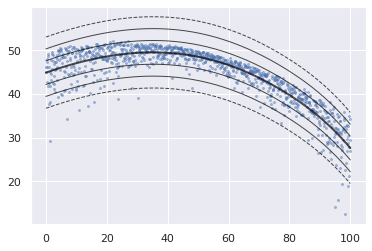

In [314]:
# plot the quantiles
plt.scatter(x, y, s = 4, alpha = 0.4)
for i, v in enumerate(zscores):
    thickness = 1
    linestyle = "-"
    if v == 0:
        thickness = 2
    if abs(v) > 2:
        linestyle = "--"
    plt.plot(inscaler.inverse_transform(synthetic_x), outscaler.inverse_transform(q[i]), linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)

## GAM, heteroscedastic noise:

$$ y \sim N(\mu, \sigma), \,\, \mu = f_1(x), \sigma = f_2(x) $$ where $f_1$ and $f_2$ are B-spline functions

In [316]:
outputsuffix = '_gam-hetero-estimate' 

In [317]:
likelihood = 'Normal'
model_type = 'bspline'

linear_mu = 'True' #trend is regressed on x
linear_sigma = 'True' #noise is also regressed on x

#no random effects on the components of mu and sigma:
random_intercept_mu = 'False'
random_slope_mu = 'False'
random_intercept_sigma = 'False'
random_slope_sigma = 'False'

centered_intercept_mu = 'True'

#for faster computation:
inscaler_type='standardize'
outscaler_type='standardize'
inscaler = ptk.util.utils.scaler(inscaler_type)
x_standardized = inscaler.fit_transform(x)
outscaler = ptk.util.utils.scaler(outscaler_type)
y_standardized = outscaler.fit_transform(y)

In [318]:
n_mcmc_samples = 1500
n_tuning_samples = 500
n_chains = 4
n_cores = 16
target_accept = 0.99

In [319]:
alg='hbr'
saveoutput='True'
savemodel='True'
binary='True'

In [320]:
ptk.normative.fit(covfile=covfile,
                  respfile=respfile,
                  log_path=log_dir,
                  saveoutput=saveoutput,
                  output_path=output_path, 
                  savemodel=savemodel,
                  binary=binary,
                  outputsuffix=outputsuffix,
                  alg=alg,
                  n_samples=n_mcmc_samples,
                  n_tuning=n_tuning_samples,
                  n_chains=n_chains,
                  cores=n_cores,
                  target_accept=target_accept,
                  inscaler=inscaler_type,
                  outscaler=outscaler_type,
                  
                  likelihood=likelihood,
                  model_type=model_type,
                  linear_mu = linear_mu,
                  linear_sigma = linear_sigma,
                  random_intercept_mu = random_intercept_mu,
                  random_slope_mu = random_slope_mu,
                  random_intercept_sigma = random_intercept_sigma,
                  random_slope_sigma = random_slope_sigma,
                  centered_intercept_mu = centered_intercept_mu
                 )


Processing data in /home/tng/Documents/phd/normative modeling/gamlss_normative_paper_with_PCN_HBR/y.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 16 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 65 seconds.


Saving model meta-data...


In [321]:
# Load the model and show the idata (the object that contains the MCMC samples)
model_path = os.path.join(output_path, f'NM_0_0{outputsuffix}.pkl')
nm = pickle.load(open(model_path,'rb'))
nm.hbr.idata.posterior

<xarray.Dataset>
Dimensions:             (chain: 4, draw: 1500, basis_functions: 8,
                         datapoints: 1000, empty: 1)
Coordinates:
  * chain               (chain) int64 0 1 2 3
  * draw                (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
  * basis_functions     (basis_functions) int64 0 1 2 3 4 5 6 7
  * datapoints          (datapoints) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * empty               (empty) int64 0
Data variables:
    slope_mu            (chain, draw, basis_functions) float64 -1.24 ... -2.335
    intercept_mu        (chain, draw) float64 0.08581 -0.2825 ... -0.2428
    slope_sigma         (chain, draw, basis_functions) float64 0.08325 ... -0...
    intercept_sigma     (chain, draw) float64 -4.127 -4.852 ... -4.714 -4.744
    mu_samples          (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-01-10T13:38:48.470843
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              65.15158438682556
    tuning_steps:               500

In [322]:
# Get the MCMC-estimated quantiles
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

zscores = np.arange(-3, 4)[:,np.newaxis]

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 200
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

q = nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores)

Sampling: [y_like]


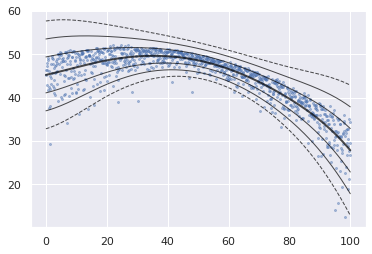

In [323]:
# plot the quantiles
plt.scatter(x, y, s = 4, alpha = 0.4)
for i, v in enumerate(zscores):
    thickness = 1
    linestyle = "-"
    if v == 0:
        thickness = 2
    if abs(v) > 2:
        linestyle = "--"
    plt.plot(inscaler.inverse_transform(synthetic_x), outscaler.inverse_transform(q[i]), linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)

## GAMLSS version 1
$$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$$
$$\mu = f_1(x), \sigma = f_2(x), \epsilon = \beta_{\epsilon}, \delta = \beta_{\delta}$$

In [24]:
outputsuffix = '_gamlss-semi-estimate' 

In [25]:
likelihood = 'SHASHo2'
model_type = 'bspline'

# only mu and sigma are regressed on x
linear_mu = 'True' 
linear_sigma = 'True' 
linear_epsilon = 'False'
linear_delta = 'False'

#no random effects on the components of model parameters
random_intercept_mu = 'False'
random_slope_mu = 'False'
random_intercept_sigma = 'False'
random_slope_sigma = 'False'
random_intercept_epsilon = 'False'
random_slope_epsilon = 'False'
random_intercept_delta = 'False'
random_slope_delta = 'False'

centered_intercept_mu = 'True'

#for faster computation:
inscaler_type='standardize'
outscaler_type='standardize'
inscaler = ptk.util.utils.scaler(inscaler_type)
x_standardized = inscaler.fit_transform(x)
outscaler = ptk.util.utils.scaler(outscaler_type)
y_standardized = outscaler.fit_transform(y)

In [26]:
n_mcmc_samples = 1500
n_tuning_samples = 500
n_chains = 4
n_cores = 16
target_accept = 0.99

In [27]:
alg='hbr'
saveoutput='True'
savemodel='True'
binary='True'

In [28]:
ptk.normative.fit(covfile=covfile,
                  respfile=respfile,
                  log_path=log_dir,
                  saveoutput=saveoutput,
                  output_path=output_path, 
                  savemodel=savemodel,
                  binary=binary,
                  outputsuffix=outputsuffix,
                  alg=alg,
                  n_samples=n_mcmc_samples,
                  n_tuning=n_tuning_samples,
                  n_chains=n_chains,
                  cores=n_cores,
                  target_accept=target_accept,
                  inscaler=inscaler_type,
                  outscaler=outscaler_type,
                  
                  likelihood=likelihood,
                  model_type=model_type,
                  
                  linear_mu = linear_mu,
                  linear_sigma = linear_sigma,
                  linear_epsilon = linear_epsilon,
                  linear_delta = linear_delta,
                  
                  random_intercept_mu = random_intercept_mu,
                  random_slope_mu = random_slope_mu,
                  random_intercept_sigma = random_intercept_sigma,
                  random_slope_sigma = random_slope_sigma,
                  random_intercept_epsilon = random_intercept_epsilon,
                  random_slope_epsilon = random_slope_epsilon,
                  random_intercept_delta = random_intercept_delta,
                  random_slope_delta = random_slope_delta,
                  
                  centered_intercept_mu = centered_intercept_mu
                 )


Processing data in /home/tng/Documents/phd/normative modeling/gamlss_normative_paper_with_PCN_HBR/y.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 16 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 575 seconds.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


Saving model meta-data...


In [29]:
# Load the model and show the idata (the object that contains the MCMC samples)
model_path = os.path.join(output_path, f'NM_0_0{outputsuffix}.pkl')
nm = pickle.load(open(model_path,'rb'))
nm.hbr.idata.posterior

<xarray.Dataset>
Dimensions:             (chain: 4, draw: 1500, basis_functions: 8,
                         datapoints: 1000, empty: 1)
Coordinates:
  * chain               (chain) int64 0 1 2 3
  * draw                (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
  * basis_functions     (basis_functions) int64 0 1 2 3 4 5 6 7
  * datapoints          (datapoints) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * empty               (empty) int64 0
Data variables:
    slope_mu            (chain, draw, basis_functions) float64 -1.343 ... 0.483
    intercept_mu        (chain, draw) float64 0.6661 0.7002 ... -0.7189 -0.8938
    slope_sigma         (chain, draw, basis_functions) float64 0.2032 ... -0....
    intercept_sigma     (chain, draw) float64 -0.4843 -0.9692 ... -1.092 -1.09
    epsilon             (chain, draw) float64 -1.198 -1.524 ... -1.306 -1.169
    delta               (chain, draw) float64 0.662 0.7382 ... 0.6957 0.5671
    mu_samples          (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    epsilon_samples     (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-01-15T09:39:18.645716
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              575.4222645759583
    tuning_steps:               500

In [30]:
# Get the MCMC-estimated quantiles
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

zscores = np.arange(-3, 4)[:,np.newaxis]

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 200
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

q = nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores)

Sampling: [y_like]


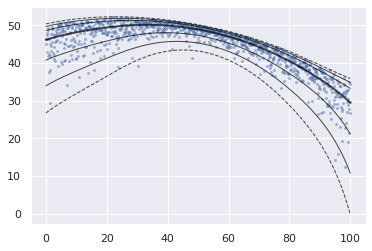

In [31]:
# plot the quantiles
plt.scatter(x, y, s = 4, alpha = 0.4)
for i, v in enumerate(zscores):
    thickness = 1
    linestyle = "-"
    if v == 0:
        thickness = 2
    if abs(v) > 2:
        linestyle = "--"
    plt.plot(inscaler.inverse_transform(synthetic_x), outscaler.inverse_transform(q[i]), linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)

## GAMLSS version 2
$$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$$
$$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$$

In [324]:
outputsuffix = '_gamlss-full-estimate' 

In [18]:
Welikelihood = 'SHASHo2'
model_type = 'bspline'

# all the 4 model parameters are regressed on x
linear_mu = 'True' 
linear_sigma = 'True' 
linear_epsilon = 'True'
linear_delta = 'True'

#no random effects on the components of model parameters
random_intercept_mu = 'False'
random_slope_mu = 'False'
random_intercept_sigma = 'False'
random_slope_sigma = 'False'
random_intercept_epsilon = 'False'
random_slope_epsilon = 'False'
random_intercept_delta = 'False'
random_slope_delta = 'False'

centered_intercept_mu = 'True'

#for faster computation:
inscaler_type='standardize'
outscaler_type='standardize'
inscaler = ptk.util.utils.scaler(inscaler_type)
x_standardized = inscaler.fit_transform(x)
outscaler = ptk.util.utils.scaler(outscaler_type)
y_standardized = outscaler.fit_transform(y)

In [331]:
n_mcmc_samples = 1500
n_tuning_samples = 500
n_chains = 4
n_cores = 16
target_accept = 0.99

In [332]:
alg='hbr'
saveoutput='True'
savemodel='True'
binary='True'

In [333]:
ptk.normative.fit(covfile=covfile,
                  respfile=respfile,
                  log_path=log_dir,
                  saveoutput=saveoutput,
                  output_path=output_path, 
                  savemodel=savemodel,
                  binary=binary,
                  outputsuffix=outputsuffix,
                  alg=alg,
                  n_samples=n_mcmc_samples,
                  n_tuning=n_tuning_samples,
                  n_chains=n_chains,
                  cores=n_cores,
                  target_accept=target_accept,
                  inscaler=inscaler_type,
                  outscaler=outscaler_type,
                  
                  likelihood=likelihood,
                  model_type=model_type,
                  
                  linear_mu = linear_mu,
                  linear_sigma = linear_sigma,
                  linear_epsilon = linear_epsilon,
                  linear_delta = linear_delta,
                  
                  random_intercept_mu = random_intercept_mu,
                  random_slope_mu = random_slope_mu,
                  random_intercept_sigma = random_intercept_sigma,
                  random_slope_sigma = random_slope_sigma,
                  random_intercept_epsilon = random_intercept_epsilon,
                  random_slope_epsilon = random_slope_epsilon,
                  random_intercept_delta = random_intercept_delta,
                  random_slope_delta = random_slope_delta,
                  
                  centered_intercept_mu = centered_intercept_mu
                 )


Processing data in /home/tng/Documents/phd/normative modeling/gamlss_normative_paper_with_PCN_HBR/y.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 16 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Sampling 4 chains for 500 tune and 1_500 draw iterations (2_000 + 6_000 draws total) took 636 seconds.


Saving model meta-data...


In [334]:
# Load the model and show the idata (the object that contains the MCMC samples)
model_path = os.path.join(output_path, f'NM_0_0{outputsuffix}.pkl')
nm = pickle.load(open(model_path,'rb'))
nm.hbr.idata.posterior

<xarray.Dataset>
Dimensions:             (chain: 4, draw: 1500, basis_functions: 8,
                         datapoints: 1000, empty: 1)
Coordinates:
  * chain               (chain) int64 0 1 2 3
  * draw                (draw) int64 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
  * basis_functions     (basis_functions) int64 0 1 2 3 4 5 6 7
  * datapoints          (datapoints) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * empty               (empty) int64 0
Data variables: (12/14)
    slope_mu            (chain, draw, basis_functions) float64 -1.435 ... -1.417
    intercept_mu        (chain, draw) float64 0.8288 0.7551 ... -0.8907 -0.3847
    slope_sigma         (chain, draw, basis_functions) float64 0.1778 ... 0.1461
    intercept_sigma     (chain, draw) float64 -0.9884 -1.248 ... -1.134 -0.3484
    slope_epsilon       (chain, draw, basis_functions) float64 0.2513 ... -0....
    intercept_epsilon   (chain, draw) float64 -1.212 -1.092 ... -0.6818 -0.7548
    ...                  ...
    mu_samples          (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sigma_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    epsilon_samples     (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_samples       (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_plus_samples  (chain, draw, empty) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-01-10T13:54:28.024802
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              636.4154937267303
    tuning_steps:               500

In [335]:
# Get the MCMC-estimated quantiles
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

zscores = np.arange(-3, 4)[:,np.newaxis]

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 200
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

q = nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores)

Sampling: [y_like]


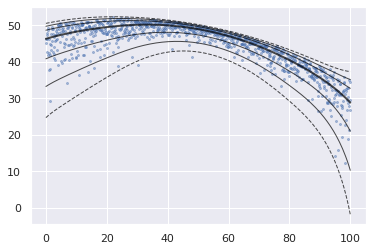

In [336]:
# plot the quantiles
plt.scatter(x, y, s = 4, alpha = 0.4)
for i, v in enumerate(zscores):
    thickness = 1
    linestyle = "-"
    if v == 0:
        thickness = 2
    if abs(v) > 2:
        linestyle = "--"
    plt.plot(inscaler.inverse_transform(synthetic_x), outscaler.inverse_transform(q[i]), linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)

# Summary

We will re plot Fig 1 of https://www.biorxiv.org/content/10.1101/2021.06.14.448106v1

In [17]:
models_suffixes_list = ['_linear-homo-estimate', '_gam-homo-estimate', '_gam-hetero-estimate', 
                        '_gamlss-semi-estimate','_gamlss-full-estimate']
models_names_list = ['NM_0_0' + s for s in models_suffixes_list]

In [18]:
nm_list = []
for model_name in models_names_list:
    model_path = output_path + model_name + '.pkl'
    nm_list.append(pickle.load(open(model_path,'rb')))

Get the MCMC-estimated quantiles:

The function get_mcmc_quantiles compute quantiles based on the posterior predictive. If the posterior predictive already exists in the idata, it is not taken into account. Rather it is computed again according to the batch effects specified in the call to the function (they are set to 0 if None). 

In [19]:
minx = np.min(x_standardized)
maxx = np.max(x_standardized)

#zscores = np.arange(-3, 4)[:,np.newaxis]
zscores = np.arange(-3, 4)[:,np.newaxis] #99% quantiles

# We need to provide a matrix of shape [N,d]. In this case d=1, so we need to expand this matrix with a single 'empty' dimension.
# We can do this by using the np.newaxis in this way.
n_synthetic_samples = 1000
synthetic_x = np.linspace(minx, maxx, n_synthetic_samples)[:,np.newaxis]

In [20]:
q_list = []
for nm in nm_list :
    q_list.append(nm.get_mcmc_quantiles(synthetic_x, z_scores=zscores))

Sampling: [y_like]


Sampling: [y_like]


Sampling: [y_like]


Sampling: [y_like]


Sampling: [y_like]


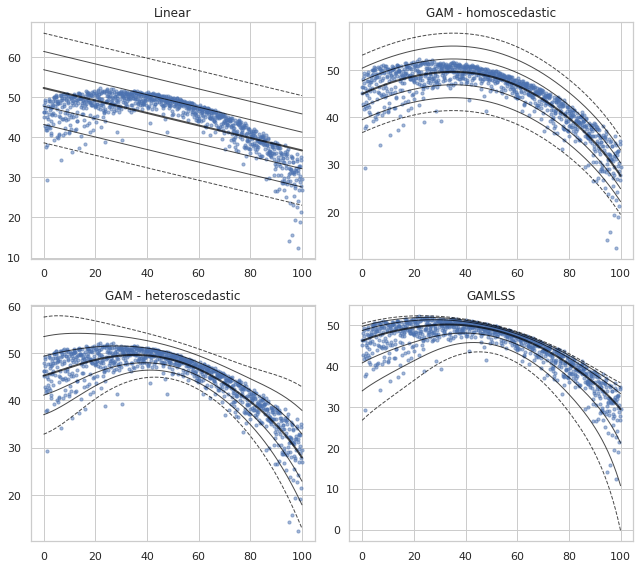

In [21]:
q_list_plot = q_list[:-1] 
titles_list = ['Linear', 'GAM - homoscedastic', 'GAM - heteroscedastic', 'GAMLSS']
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(9, 8))

for iax in range(len(q_list_plot)) :

    ax[iax//2, iax%2].scatter(x, y, s = 10, alpha = 0.5)
    for i, v in enumerate(zscores):
        thickness = 1
        linestyle = "-"
        if v == 0:
            thickness = 2
        if abs(v) > 2:
            linestyle = "--"
        ax[iax//2, iax%2].plot(inscaler.inverse_transform(synthetic_x), 
                               outscaler.inverse_transform(q_list_plot[iax][i]), 
             linewidth = thickness, linestyle = linestyle, color = 'black', alpha = 0.7)
        ax[iax//2, iax%2].set_title(titles_list[iax])
fig.tight_layout()
#fig.savefig('paper_fig1.png', bbox_inches="tight")

We can also show an example of what is done within the function get_mcmc_quantiles. 

For a gaussian likelihood $$\tilde q  = z_{score} * \sigma + \mu$$

For SHASH likelihood

* SHASHo $$\tilde q = S_{inv}(z_{score}, \epsilon, \delta) * \sigma + \mu$$
            
          
* SHASHo2 $$\tilde q = S_{inv}(z_{score}, \epsilon, \delta) * (\sigma / \delta) + \mu$$

where $$S_{inv}(z, e, d) = sinh((arcsinh(z) + e) / d)$$

For SHASHb: https://github.com/amarquand/PCNtoolkit/blob/77341474f42d182315ec151df03d1fbbfa3d1dff/pcntoolkit/normative_model/norm_hbr.py

We do the case of GAM with heteroscedastic noise. 

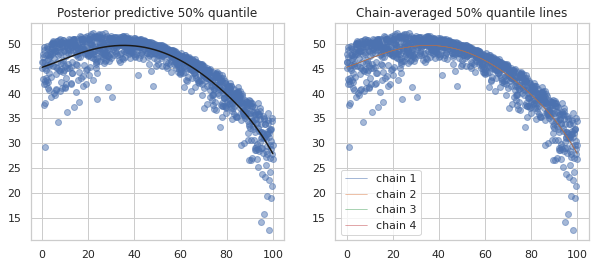

In [22]:
#Handmade example: for a gaussian likelihood (q \tilde = zscore * sigma + mu)

nm = nm_list[2] #GAM - heteroscedastic noise
post_pred = nm.hbr.idata.posterior_predictive

#mean (50% quantile) : zscore = 0
pred_q50_mcmc = 0*post_pred['sigma_plus_samples'] + post_pred['mu_samples']
pred_q50 = np.mean(pred_q50_mcmc, axis=0).mean(axis=0)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].scatter(x, y, alpha=0.5)
ax[0].plot(x, outscaler.inverse_transform(pred_q50), color='k') ;
ax[0].set_title('Posterior predictive 50% quantile')

#chain-averaged q50 lines: not much interest because they are very close but whatever
ax[1].scatter(x, y, alpha=0.5)
for i_chain in range(pred_q50_mcmc.shape[0]) :
    ax[1].plot(x, outscaler.inverse_transform(pred_q50_mcmc.mean(axis=1)[i_chain]), linewidth=0.5,
              label='chain ' + str(i_chain+1))
ax[1].set_title('Chain-averaged 50% quantile lines')
ax[1].legend();

# Vizualize models

For example, we can access description of the GAM model with heterosceastic noise (posterior updated) :

In [23]:
nm_list[2].hbr.get_model(x, y, np.zeros(len(y)))

          slope_mu ~ Normal(-0.185, 1.21)
      intercept_mu ~ Normal(-0.665, 0.366)
       slope_sigma ~ Normal(-0.526, 1.92)
   intercept_sigma ~ Normal(-4.39, 0.385)
        mu_samples ~ Deterministic(f(intercept_mu, slope_mu))
     sigma_samples ~ Deterministic(f(intercept_sigma, slope_sigma))
sigma_plus_samples ~ Deterministic(f(intercept_sigma, slope_sigma))
            y_like ~ Normal(mu_samples, sigma_plus_samples)

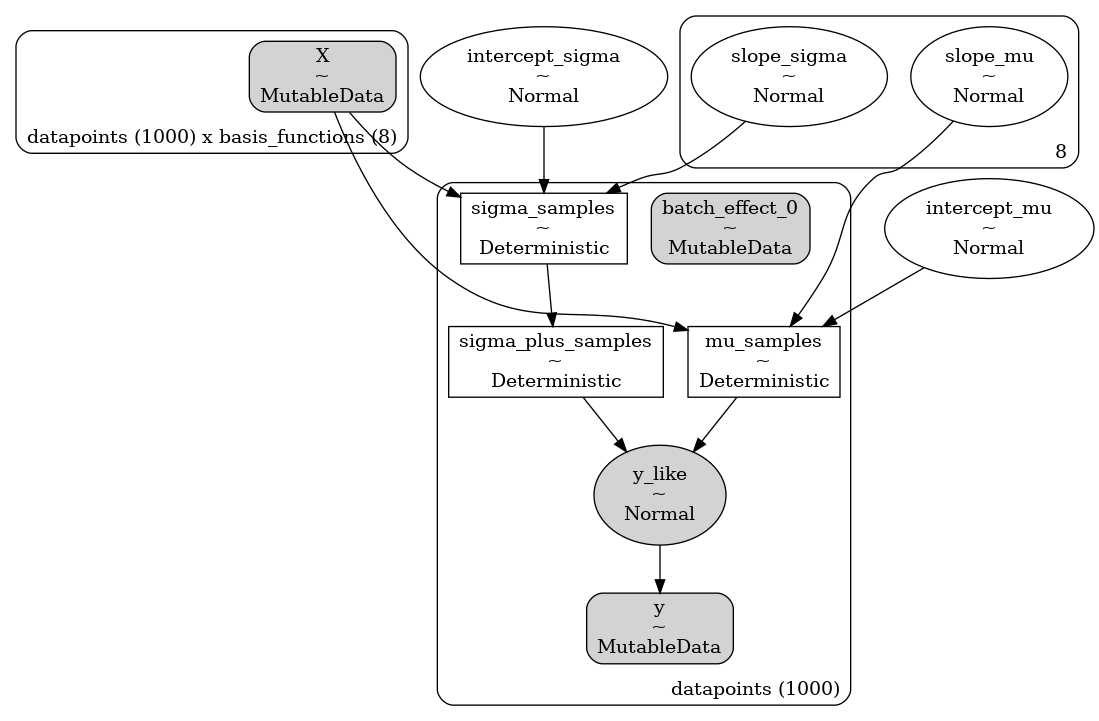

In [24]:
pm.model_to_graphviz(nm_list[2].hbr.get_model(x, y, np.zeros(len(y))))

# Diagnostics for MCMC sampling

In [25]:
model_names = ['Linear', 'GAM - hom', 'GAM - het', 'GAMLSS half', 'GAMLSS full']

## R-hat

arviz - WARNING - Shape validation failed: input_shape: (4, 0), minimum_shape: (chains=2, draws=4)


Linear


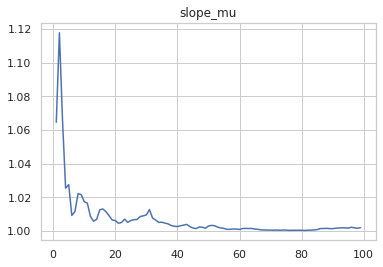

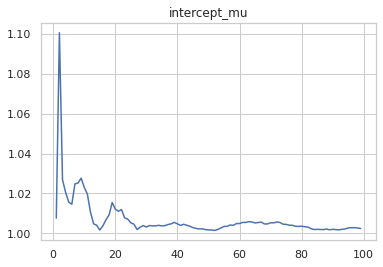

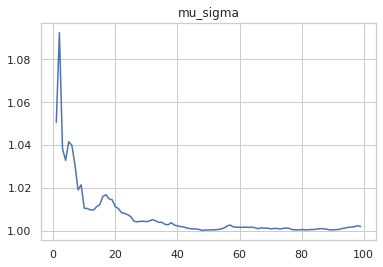

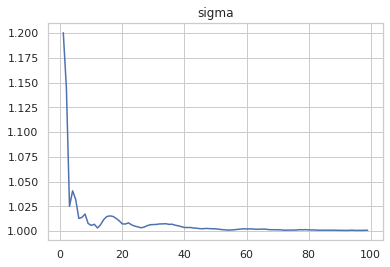

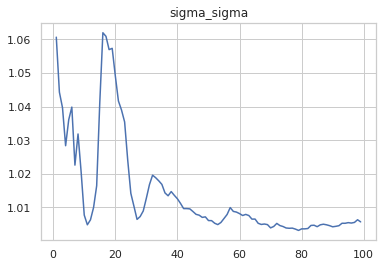

GAM - hom


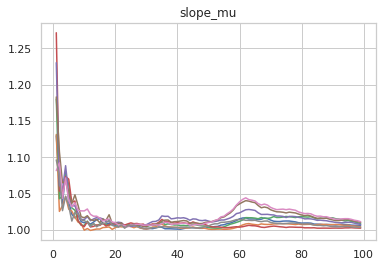

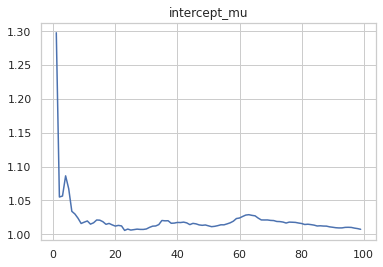

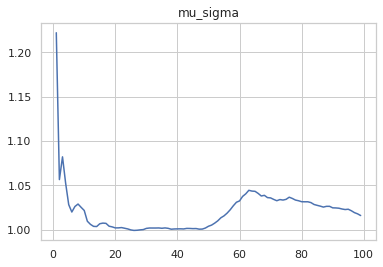

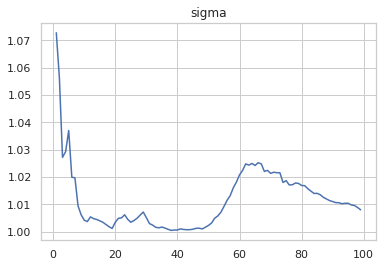

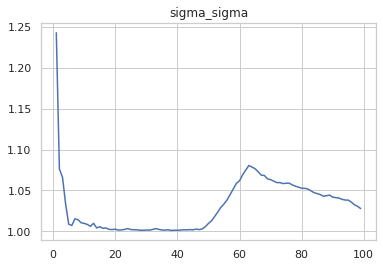

GAM - het


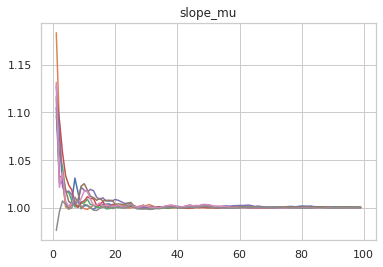

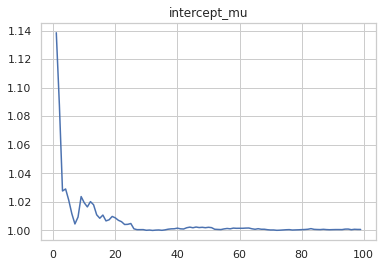

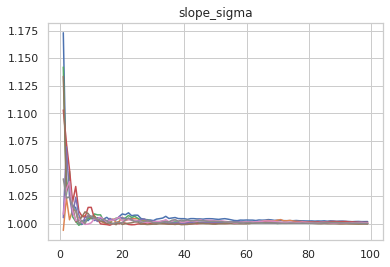

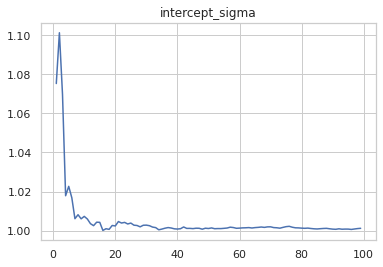

GAMLSS half


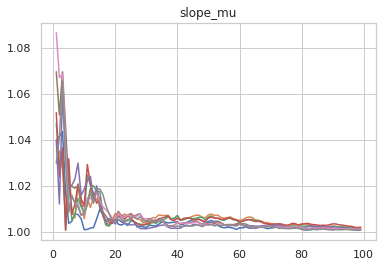

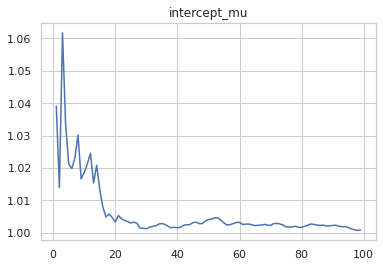

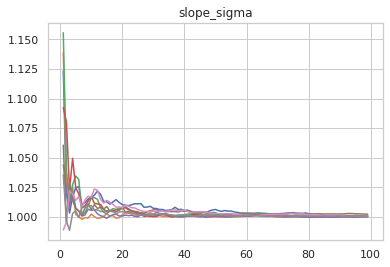

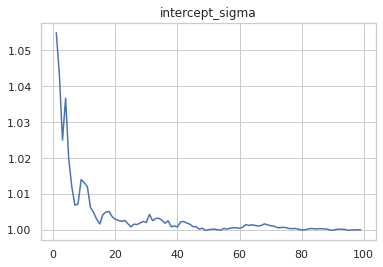

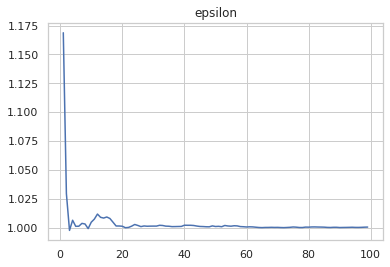

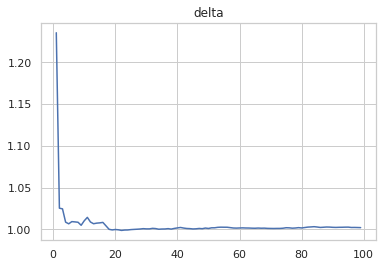

GAMLSS full


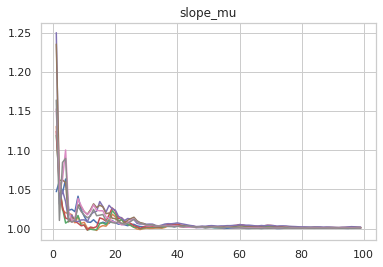

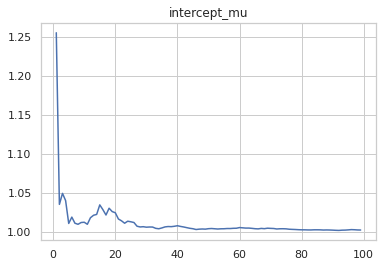

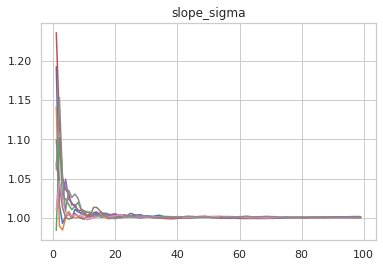

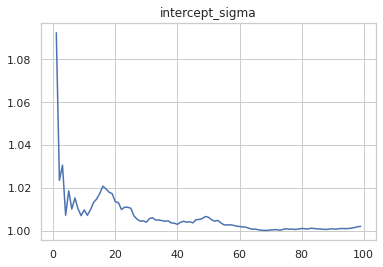

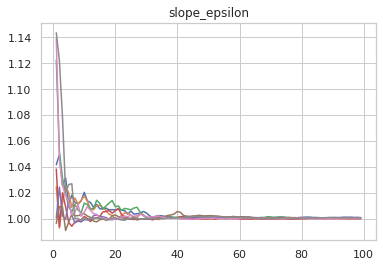

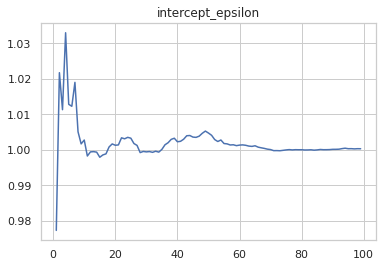

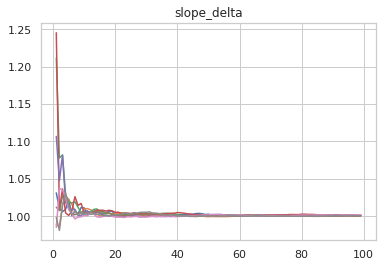

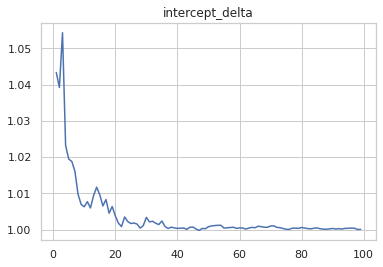

In [26]:
for i, nm in enumerate(nm_list) :
    Rhat = nm.hbr.Rhats()
    print(model_names[i])
    for r in Rhat.keys():
        plt.plot(Rhat[r])
        plt.title(r)
        plt.show()

In [27]:
for i, nm in enumerate(nm_list) :
    rhat_high = (az.rhat(nm.hbr.idata.posterior) >= 1.01).sum()
    if int(rhat_high.to_array().sum()) > 0 :
        print(model_names[i], 'has values of R-hat > 1.01 ')
        print(rhat_high)

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value 

GAM - hom has values of R-hat > 1.01 
<xarray.Dataset>
Dimensions:             ()
Data variables:
    slope_mu            int64 1
    intercept_mu        int64 0
    mu_sigma            int64 1
    sigma               int64 0
    sigma_sigma         int64 1
    mu_samples          int64 0
    sigma_samples       int64 0
    sigma_plus_samples  int64 0


## Correlations

Ideally, we don't want high linear correlation between model parameters samples

Linear


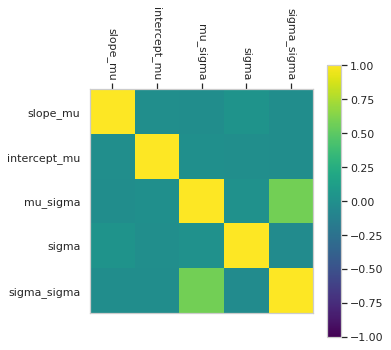

GAM - hom


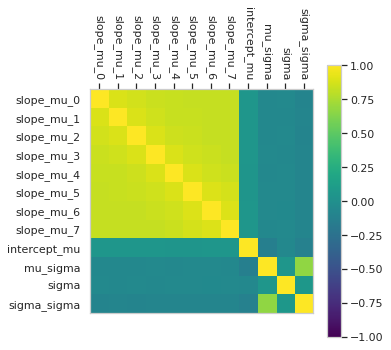

GAM - het


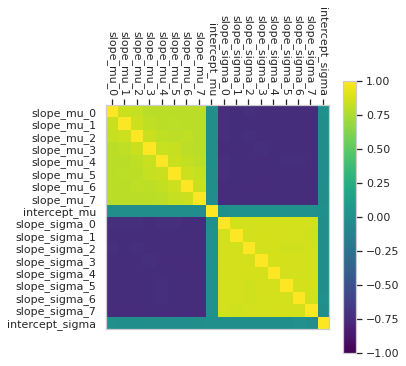

GAMLSS half


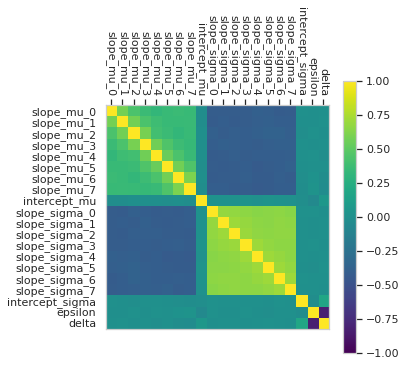

GAMLSS full


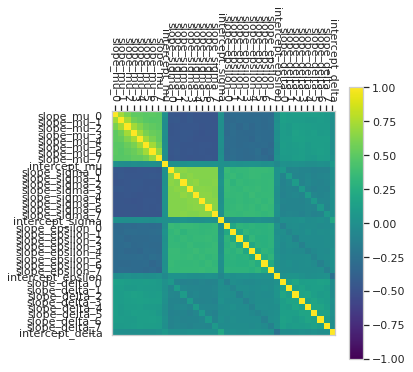

In [28]:
for i, nm in enumerate(nm_list) :
    print(model_names[i])
    posterior = az.extract(nm.hbr.idata, var_names=['~samples'], filter_vars='like')
    # nm.hbr.trace['epsilon']
    paramdf = pd.DataFrame()
    for v in posterior.keys():
        flattened = np.reshape(posterior[v].data, (posterior[v].data.shape[-1],-1))
        if flattened.shape[1]>1:
            for i in range(flattened.shape[1]):
                paramdf[f'{v}_{i}'] = flattened[:,i]
        else:
            paramdf[f'{v}'] = flattened[:,0]
            
    l = np.stack(paramdf.values, axis = 1)
    c = np.corrcoef(l)
    fig, ax = plt.subplots(1,1,figsize=(5,5))
    plt.grid(False)
    plt.imshow(c, vmin = -1, vmax = 1, cmap = 'viridis')
    plt.xticks(np.arange(len(paramdf.keys())),paramdf.keys(), rotation = -90)
    ax.xaxis.tick_top()

    plt.yticks(np.arange(len(paramdf.keys())),paramdf.keys())
    plt.colorbar()

    plt.show()

# Manage the outputs

## Slopes with splines 

How to work with the decomposed slopes of coefficients?

The slope for mu is decomposed in coefficients in a spline basis. We multiply its coefficients with their corresponding basis functions and take the sum. 

In [29]:
nm = nm_list[-1] #GAMLSS regression splines on all parameters

In [30]:
#we just get the mean, but we could also wok with all the mcmc samples
slope_mu_bcoefs = nm.hbr.idata.posterior['slope_mu'].mean(axis=0).mean(axis=0)
slope_mu_bcoefs.shape

(8,)

In [31]:
intercept_mu = float(nm.hbr.idata.posterior['intercept_mu'].mean(axis=0).mean(axis=0))

We can construct a spline basis:

In [32]:
spline_basis = ptk.model.hbr.bspline_fit(x_standardized[:, np.newaxis], nm.configs['order'], nm.configs['nknots'])

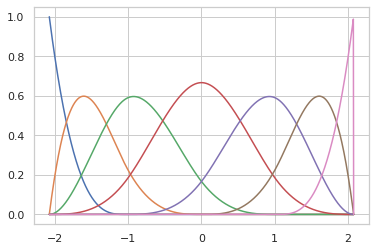

In [33]:
spline_basis[0].plot()

But the basis is actually already stored in model data:

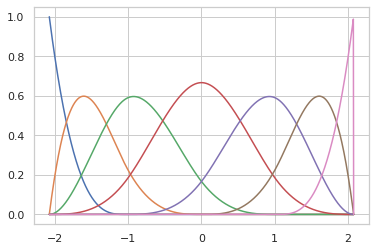

In [34]:
nm.hbr.bsp[0].plot() #it is the same basis

In [35]:
nm.hbr.bsp[0].knot_vector == spline_basis[0].knot_vector

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [36]:
nm.hbr.bsp[0].p == spline_basis[0].p

True

We can get x in the spline basis:

In [37]:
x_standardized_spline = ptk.model.hbr.bspline_transform(x_standardized[:, np.newaxis], nm.hbr.bsp)
x_standardized_spline.shape

(1000, 7)

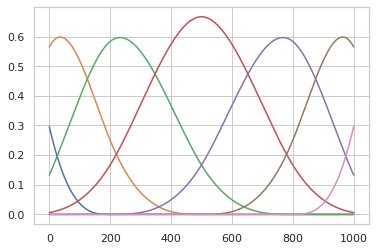

In [38]:
plt.plot(x_standardized_spline) ;

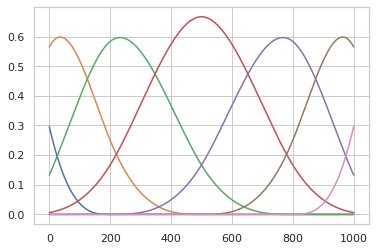

In [39]:
#We can also directly use the collmat() method:
x_standardized_spline_2 = [nm.hbr.bsp[0].collmat(t) for t in x_standardized]
plt.plot(x_standardized_spline_2) ;

Note that the spline basis has 7 splines, while the model has 8 dimensions for mu. This is because we must work with phi = [x, x_in_spline_basis]. The first dimension in mu will be multiplied with the untransformed x.

In [40]:
phi = np.concatenate((x_standardized[:, np.newaxis], x_standardized_spline), axis=1)
phi.shape

(1000, 8)

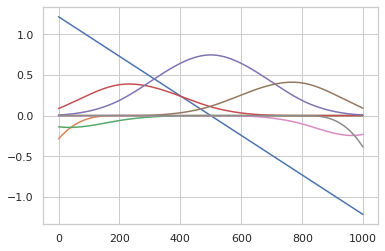

In [41]:
plt.plot(phi * np.array(slope_mu_bcoefs)) ;

In [42]:
transformed_mu_slope = np.sum(phi * np.array(slope_mu_bcoefs), axis=1)

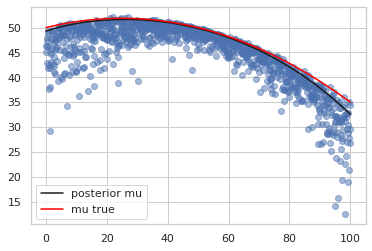

In [43]:
plt.plot(x, y, 'o', alpha=0.5) ;
plt.plot(x, outscaler.inverse_transform(intercept_mu + transformed_mu_slope), 'k', label='posterior mu') 
plt.plot(x, mu_true, color='red', label='mu true')
plt.legend() ;

Same for sigma:

In [44]:
slope_sigma_bcoefs = nm.hbr.idata.posterior['slope_sigma'].mean(axis=0).mean(axis=0)
slope_sigma_bcoefs.shape

(8,)

In [45]:
intercept_sigma = float(nm.hbr.idata.posterior['intercept_sigma'].mean(axis=0).mean(axis=0))

In [46]:
transformed_sigma_slope = np.sum(phi * np.array(slope_sigma_bcoefs), axis=1)

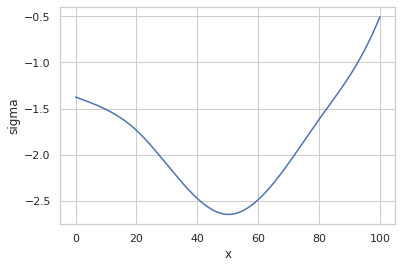

In [47]:
plt.plot(x, intercept_sigma + transformed_sigma_slope) 
plt.xlabel('x') ; plt.ylabel('sigma') ;

We see how the variance changes with x: sigma was modelled to account for the fact there is more dispersion in the data at the small and large x values than there is at the center.

But sigma is a parameter that is supposed to be positive. In the posterior predictive samples, there is two kind of samples for sigma "sigma_samples" and "sigma_plus_samples".

In [48]:
nm.hbr.idata.posterior_predictive.data_vars

Data variables:
    mu_samples          (chain, draw, datapoints) float64 0.87 0.872 ... -2.017
    sigma_samples       (chain, draw, datapoints) float64 -0.9654 ... -0.224
    sigma_plus_samples  (chain, draw, datapoints) float64 0.3227 ... 0.5874
    epsilon_samples     (chain, draw, datapoints) float64 -1.795 ... -0.7888
    delta_samples       (chain, draw, datapoints) float64 0.8182 ... 0.6244
    delta_plus_samples  (chain, draw, datapoints) float64 1.118 1.119 ... 0.9246
    y_like              (chain, draw, datapoints) float64 -0.295 ... -2.238

The transformation from sigma_samples to sigma_plus_samples is 
* log(1 + exp(sigma_samples / 3)) * 3 for normal likelihood 
* log(1 + exp(sigma_samples)) for SHASH family.

For delta samples, the transformation is log(1 + exp(delta * 10)) / 10 + 0.3.

In [49]:
#sigma_samples = np.log(1 + np.exp(nm.hbr.idata.posterior_predictive['sigma_samples']/3))*3 #if gaussian likelihood
sigma_samples = np.log(1 + np.exp(nm.hbr.idata.posterior_predictive['sigma_samples'])) #if shash likelihood
np.isclose(sigma_samples, nm.hbr.idata.posterior_predictive['sigma_plus_samples']).all()

True

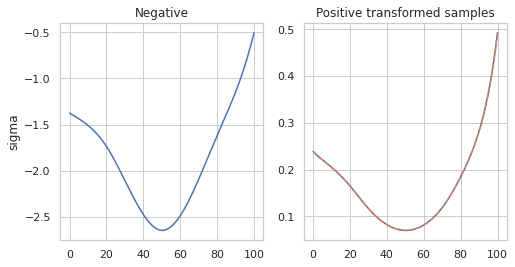

In [50]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 4), sharex=True)
ax[0].plot(x, nm.hbr.idata.posterior_predictive['sigma_samples'].mean(axis=0).mean(axis=0))
ax[1].plot(x, nm.hbr.idata.posterior_predictive['sigma_plus_samples'].mean(axis=0).mean(axis=0));
ax[1].plot(x, sigma_samples.mean(axis=0).mean(axis=0), '--')
ax[0].set_title('Negative')
ax[1].set_title('Positive transformed samples') ;
ax[0].set_ylabel('sigma') ;

When working from the posterior estimation of sigma's intercept and slope, if we apply the transformation, we get the positive sigma:

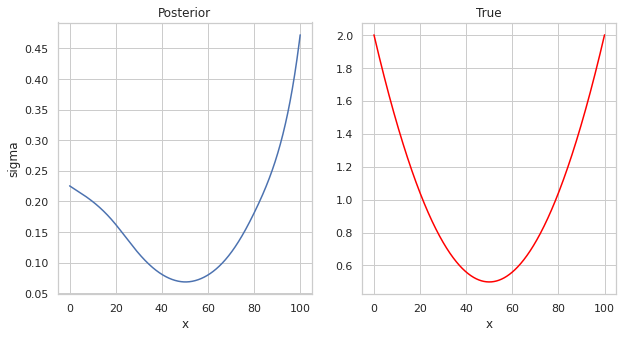

In [51]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True)
ax[0].plot(x, np.log(1 + np.exp(intercept_sigma + transformed_sigma_slope))) #if shash likelihood
#ax[0].plot(x, np.log(1 + np.exp((intercept_sigma + transformed_sigma_slope)/3))*3) #if gaussian likelihood
ax[0].set_xlabel('x') ; ax[0].set_ylabel('sigma') ; ax[1].set_xlabel('x')
ax[1].plot(x, sigmas, color='red')                
ax[0].set_title('Posterior')
ax[1].set_title('True') ;

## Exploit posterior / posterior predictive samples

We have MCMC samples, we can take advantage of that and extract credibility intervals

In [52]:
sigma_plus_samples_pp = nm.hbr.idata.posterior_predictive['sigma_plus_samples']
mu_samples_pp = outscaler.inverse_transform(nm.hbr.idata.posterior_predictive['mu_samples'])

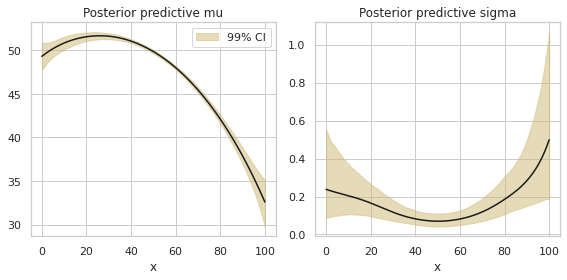

In [53]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

mu_q_l99_pp = np.quantile(mu_samples_pp, 0.005, axis=[0, 1])
mu_q_h99_pp = np.quantile(mu_samples_pp, 0.995, axis=[0, 1])
ax[0].fill_between(x, mu_q_l99_pp, mu_q_h99_pp, color='y',alpha=0.5, label='99% CI')
ax[0].plot(x, mu_samples_pp.mean(axis=1)[i_chain], 'k')
ax[0].set_title('Posterior predictive mu')

sigma_q_l99_pp = np.quantile(sigma_plus_samples_pp, 0.005, axis=[0, 1])
sigma_q_h99_pp = np.quantile(sigma_plus_samples_pp, 0.995, axis=[0, 1])
ax[1].fill_between(x, sigma_q_l99_pp, sigma_q_h99_pp, color='y',alpha=0.5)
ax[1].plot(x, sigma_plus_samples_pp.mean(axis=1)[i_chain], 'k')
ax[1].set_title('Posterior predictive sigma') 
ax[0].legend()
ax[0].set_xlabel('x') ; ax[1].set_xlabel('x')
fig.tight_layout()

Uncertainty in the estimation of sigma is higher at extreme values of x. 

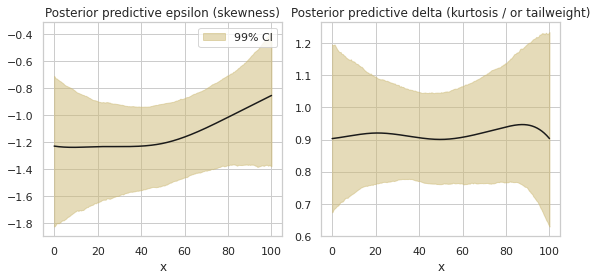

In [54]:
if nm.configs['likelihood'][:5] == 'SHASH' :

    eps_samples_pp = nm.hbr.idata.posterior_predictive['epsilon_samples']
    delta_plus_samples_pp = nm.hbr.idata.posterior_predictive['delta_plus_samples']

    fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

    eps_q_l99_pp = np.quantile(eps_samples_pp, 0.005, axis=[0, 1])
    eps_q_h99_pp = np.quantile(eps_samples_pp, 0.995, axis=[0, 1])
    ax[0].fill_between(x, eps_q_l99_pp, eps_q_h99_pp, color='y',alpha=0.5, label='99% CI')
    ax[0].plot(x, eps_samples_pp.mean(axis=1)[i_chain], 'k')
    ax[0].set_title('Posterior predictive epsilon (skewness)')

    delta_q_l99_pp = np.quantile(delta_plus_samples_pp, 0.005, axis=[0, 1])
    delta_q_h99_pp = np.quantile(delta_plus_samples_pp, 0.995, axis=[0, 1])
    ax[1].fill_between(x, delta_q_l99_pp, delta_q_h99_pp, color='y',alpha=0.5)
    ax[1].plot(x, delta_plus_samples_pp.mean(axis=1)[i_chain], 'k')
    ax[1].set_title('Posterior predictive delta (kurtosis / or tailweight)') 
    ax[0].legend()
    ax[0].set_xlabel('x') ; ax[1].set_xlabel('x')
    fig.tight_layout()

The slope of delta is quite flat which would indicate that it might not actually vary with x, and could be modeled with an intercept only. In the present case, we know that the real delta parameter is actually constant. We also know that the true epsilon is constant too.

Plot posterior predictive CI for the response $\hat y$:

In [55]:
y_hat_pp = outscaler.inverse_transform(nm.hbr.idata.posterior_predictive['y_like'])

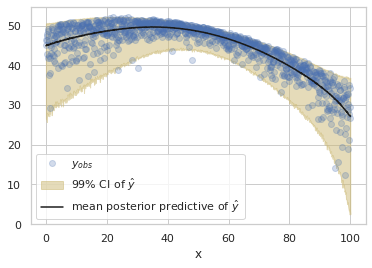

In [56]:
y_q_l99_pp = np.quantile(y_hat_pp, 0.005, axis=[0, 1])
y_q_h99_pp = np.quantile(y_hat_pp, 0.995, axis=[0, 1])
plt.plot(x, y, 'o', alpha=0.25, label='$y_{obs}$')
plt.fill_between(x, y_q_l99_pp, y_q_h99_pp, color='y',alpha=0.5, label=r'99% CI of $\hat{y}$')
plt.plot(x, y_hat_pp.mean(axis=0).mean(axis=0), 'k', label=r'mean posterior predictive of $\hat{y}$')
plt.xlabel('x')
plt.legend() ;

One can also plot the densities of the MCMC posterior predictive samples

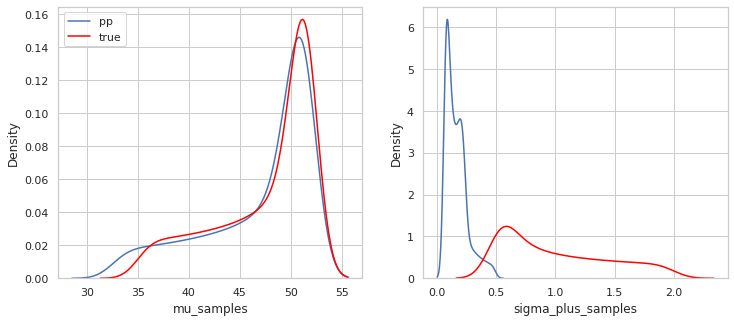

In [57]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(mu_samples_pp.mean(axis=0).mean(axis=0), ax=ax[0], label='pp')
sns.kdeplot(mu_true, ax=ax[0], color='red', label='true')

sns.kdeplot(sigma_plus_samples_pp.mean(axis=0).mean(axis=0), ax=ax[1])
sns.kdeplot(sigmas, ax=ax[1], color='red', label='true')
ax[0].legend() ;

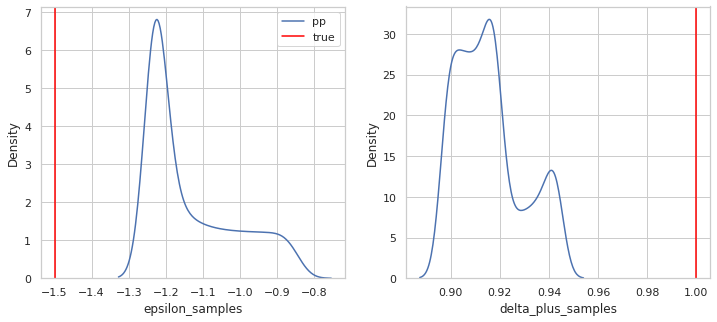

In [58]:
if nm.configs['likelihood'][:5] == 'SHASH' :
    
    fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

    sns.kdeplot(eps_samples_pp.mean(axis=0).mean(axis=0), ax=ax[0], label='pp')
    ax[0].axvline(-1.5, color='red', label='true')

    sns.kdeplot(delta_plus_samples_pp.mean(axis=0).mean(axis=0), ax=ax[1])
    ax[1].axvline(1, color='red', label='true')
    ax[0].legend() ;

Get a summary with arviz:

In [59]:
az.summary(nm_list[1].hbr.idata)

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
slope_mu[0],-0.751,0.245,-1.242,-0.332,0.006,0.004,1739.0,2812.0,1.01
slope_mu[1],-1.243,0.679,-2.566,0.009,0.013,0.009,2622.0,3016.0,1.00
slope_mu[2],-0.513,0.584,-1.646,0.583,0.012,0.009,2195.0,2514.0,1.01
slope_mu[3],0.713,0.436,-0.082,1.554,0.010,0.007,1820.0,2448.0,1.00
slope_mu[4],1.554,0.388,0.853,2.270,0.019,0.013,490.0,2237.0,1.01
slope_mu[5],0.966,0.462,0.157,1.827,0.024,0.017,382.0,632.0,1.01
slope_mu[6],-0.392,0.631,-1.539,0.735,0.033,0.030,375.0,760.0,1.01
slope_mu[7],-1.932,0.691,-3.246,-0.655,0.017,0.012,1619.0,3405.0,1.00
intercept_mu,-0.683,0.373,-1.389,-0.026,0.018,0.013,472.0,2326.0,1.01
mu_sigma,-2.708,2.026,-5.925,0.938,0.105,0.116,292.0,193.0,1.02


# Model comparison / selection

Which model is the best ?

In the present case the models are nested: The linear model is a sub-case of the gaussian GAM settings were both the mean and $\sigma$ would be constant. GAM - homoscedastik is a sub-case of GAM - heteroscedastik where the slope of sigma would be 0. The GAM are also a subcase of GAMLSS where $\epsilon = 0$ and $\delta = 1$. 
GAMLSS half is a sub-case of GAMLSS full where slopes for 3rd and 4th order parameters would be 0.


Also, here, we know the true model (GAMLSS with constant epsilon and delta) and the value of its parmeters, but in most cases the true generative model is unknown.

Optimally, we want to select one or more model that describes best the data and the generative process.

## Summarize parameter estimation 

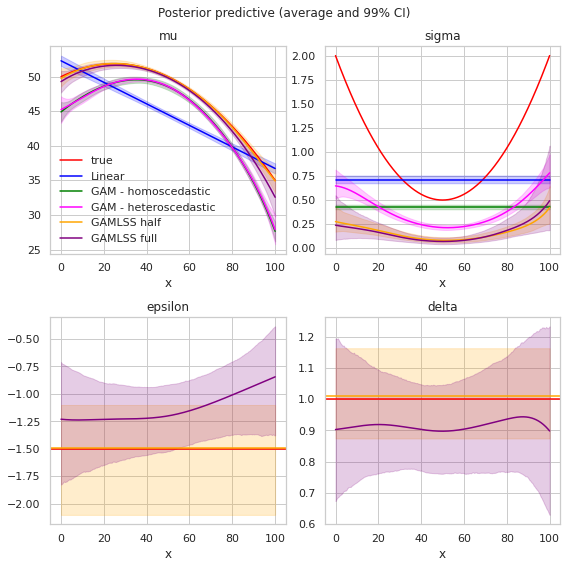

In [60]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

fig.suptitle('Posterior predictive (average and 99% CI)')
ax[0, 0].plot(x, mu_true, color='red', label='true')
ax[0, 1].plot(x, sigmas, color='red')
ax[1, 0].axhline(-1.5, color='red')
ax[1, 1].axhline(1, color='red')

colors = ['blue', 'green', 'magenta', 'orange', 'purple']
model_names = ['Linear', 'GAM - homoscedastic', 'GAM - heteroscedastic', 'GAMLSS half', 'GAMLSS full']

for imodel in range(len(nm_list)) :
    
    nm_fit = nm_list[imodel]
    
    ax[0, 0].plot(x, 
                  outscaler.inverse_transform(nm_fit.hbr.idata.posterior_predictive['mu_samples']).mean(
                      axis=0).mean(axis=0), color=colors[imodel],
                 label=model_names[imodel])
    
    ax[0, 0].fill_between(x, 
                          np.quantile(
                              outscaler.inverse_transform(nm_fit.hbr.idata.posterior_predictive['mu_samples']),
                                      .005, axis=[0, 1]),
                          np.quantile(
                              outscaler.inverse_transform(nm_fit.hbr.idata.posterior_predictive['mu_samples']),
                                      .995, axis=[0, 1]),
                          color=colors[imodel], alpha=.2)
    
    ax[0, 1].plot(x, 
                  nm_fit.hbr.idata.posterior_predictive['sigma_plus_samples'].mean(axis=0).mean(axis=0),
                  color=colors[imodel])
    
    ax[0, 1].fill_between(x, 
                          np.quantile(nm_fit.hbr.idata.posterior_predictive['sigma_plus_samples'],
                                      .005, axis=[0, 1]),
                          np.quantile(nm_fit.hbr.idata.posterior_predictive['sigma_plus_samples'],
                                      .995, axis=[0, 1]),
                          color=colors[imodel], alpha=.2)
    
    if nm_fit.configs['likelihood'][:5] == 'SHASH' :
        
        if nm_fit.configs['linear_epsilon'] == True :
            ax[1, 0].plot(x, 
                          nm_fit.hbr.idata.posterior_predictive['epsilon_samples'].mean(axis=0).mean(axis=0),
                          color=colors[imodel])
            
            ax[1, 0].fill_between(x, 
                      np.quantile(nm_fit.hbr.idata.posterior_predictive['epsilon_samples'],
                                  .005, axis=[0, 1]),
                      np.quantile(nm_fit.hbr.idata.posterior_predictive['epsilon_samples'],
                                  .995, axis=[0, 1]),
                      color=colors[imodel], alpha=.2)
                
                
        else :
            ax[1, 0].axhline(nm_fit.hbr.idata.posterior_predictive['epsilon_samples'].mean(axis=0).mean(axis=0),
                            color=colors[imodel])
            
            ax[1, 0].fill_between(x, 
                                  np.quantile(nm_fit.hbr.idata.posterior_predictive['epsilon_samples'],
                                              .005, axis=[0, 1]),
                                  np.quantile(nm_fit.hbr.idata.posterior_predictive['epsilon_samples'],
                                              .995, axis=[0, 1]),
                                  color=colors[imodel], alpha=.2)
            
            
        if nm_fit.configs['linear_delta'] == True :
            ax[1, 1].plot(x, 
                          nm_fit.hbr.idata.posterior_predictive['delta_plus_samples'].mean(axis=0).mean(axis=0),
                          color=colors[imodel])
            
            ax[1, 1].fill_between(x, 
                                  np.quantile(nm_fit.hbr.idata.posterior_predictive['delta_plus_samples'],
                                              .005, axis=[0, 1]),
                                  np.quantile(nm_fit.hbr.idata.posterior_predictive['delta_plus_samples'],
                                              .995, axis=[0, 1]),
                                  color=colors[imodel], alpha=.2)
                
        else :
            ax[1, 1].axhline(nm_fit.hbr.idata.posterior_predictive['delta_plus_samples'].mean(axis=0).mean(axis=0),
                             color=colors[imodel])
            
            ax[1, 1].fill_between(x, 
                                  np.quantile(nm_fit.hbr.idata.posterior_predictive['delta_plus_samples'],
                                              .005, axis=[0, 1]),
                                  np.quantile(nm_fit.hbr.idata.posterior_predictive['delta_plus_samples'],
                                              .995, axis=[0, 1]),
                                  color=colors[imodel], alpha=.2)

for a in ax.flatten():
    a.set_xlabel('x')
ax[0, 0].legend(loc='lower left', frameon=False) 
ax[0, 0].set_title('mu')
ax[0, 1].set_title('sigma')
ax[1, 0].set_title('epsilon')
ax[1, 1].set_title('delta') 
fig.tight_layout()
fig.savefig('models_pp_params.png', bbox_inches='tight')

Uncertainty in GAMLSS version 2 is high and the estimated mean is less close to the true value than that of GAMLSS version 1 (which actually is the true model).

By the way, we can also plot the priors:

Sampling: [intercept_mu, mu_sigma, sigma, sigma_sigma, slope_mu, y_like]
Sampling: [intercept_mu, mu_sigma, sigma, sigma_sigma, slope_mu, y_like]
Sampling: [intercept_mu, intercept_sigma, slope_mu, slope_sigma, y_like]
Sampling: [delta, epsilon, intercept_mu, intercept_sigma, slope_mu, slope_sigma, y_like]
Sampling: [intercept_delta, intercept_epsilon, intercept_mu, intercept_sigma, slope_delta, slope_epsilon, slope_mu, slope_sigma, y_like]


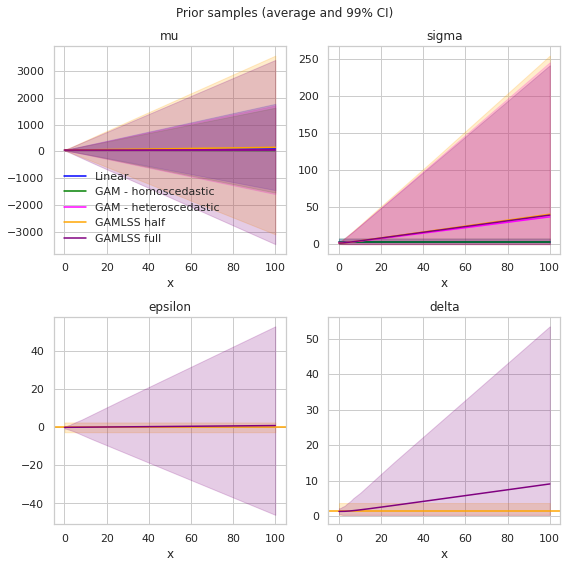

In [68]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

fig.suptitle('Prior samples (average and 99% CI)')

colors = ['blue', 'green', 'magenta', 'orange', 'purple']
model_names = ['Linear', 'GAM - homoscedastic', 'GAM - heteroscedastic', 'GAMLSS half', 'GAMLSS full']
n_samples = 1000

for imodel in range(len(nm_list)) :
    model_copy = deepcopy(nm_list[imodel]) #use a copy not to erase the posterior predictive and sample stats etc
    nm_prior = model_copy.hbr.sample_prior_predictive(x, np.zeros([x.shape[0], 1]), n_samples)
    
    ax[0, 0].plot(x, 
                  outscaler.inverse_transform(nm_prior.prior['mu_samples']).mean(axis=(0,1)), 
                  color=colors[imodel],
                  label=model_names[imodel])
    
    ax[0, 0].fill_between(x, 
                          np.quantile(
                              outscaler.inverse_transform(nm_prior.prior['mu_samples']),
                                      .005, axis=[0, 1]),
                          np.quantile(
                              outscaler.inverse_transform(nm_prior.prior['mu_samples']),
                                      .995, axis=[0, 1]),
                          color=colors[imodel], alpha=.2)
    
    ax[0, 1].plot(x, nm_prior.prior['sigma_plus_samples'].mean(axis=(0, 1)),
                  color=colors[imodel])
    
    ax[0, 1].fill_between(x, 
                          np.quantile(nm_prior.prior['sigma_plus_samples'],
                                      .005, axis=[0, 1]),
                          np.quantile(nm_prior.prior['sigma_plus_samples'],
                                      .995, axis=[0, 1]),
                          color=colors[imodel], alpha=.2)
    
    
    if nm_list[imodel].configs['likelihood'][:5] == 'SHASH' :
        
        if nm_list[imodel].configs['linear_epsilon'] == True :
            ax[1, 0].plot(x, nm_prior.prior['epsilon_samples'].mean(axis=(0, 1)),
                          color=colors[imodel])
            
            ax[1, 0].fill_between(x, 
                      np.quantile(nm_prior.prior['epsilon_samples'],
                                  .005, axis=[0, 1]),
                      np.quantile(nm_prior.prior['epsilon_samples'],
                                  .995, axis=[0, 1]),
                      color=colors[imodel], alpha=.2)
                
                
        else :
            ax[1, 0].axhline(nm_prior.prior['epsilon_samples'].mean(axis=(0, 1)),
                            color=colors[imodel])
            
            ax[1, 0].fill_between(x, 
                                  np.quantile(nm_prior.prior['epsilon_samples'],
                                              .005, axis=[0, 1]),
                                  np.quantile(nm_prior.prior['epsilon_samples'],
                                              .995, axis=[0, 1]),
                                  color=colors[imodel], alpha=.2)
            
            
        if nm_list[imodel].configs['linear_delta'] == True :
            ax[1, 1].plot(x, nm_prior.prior['delta_plus_samples'].mean(axis=(0,1)),
                          color=colors[imodel])
            
            ax[1, 1].fill_between(x, 
                                  np.quantile(nm_prior.prior['delta_plus_samples'],
                                              .005, axis=[0, 1]),
                                  np.quantile(nm_prior.prior['delta_plus_samples'],
                                              .995, axis=[0, 1]),
                                  color=colors[imodel], alpha=.2)
                
        else :
            ax[1, 1].axhline(nm_prior.prior['delta_plus_samples'].mean(axis=(0, 1)),
                             color=colors[imodel])
            
            ax[1, 1].fill_between(x, 
                                  np.quantile(nm_prior.prior['delta_plus_samples'],
                                              .005, axis=[0, 1]),
                                  np.quantile(nm_prior.prior['delta_plus_samples'],
                                              .995, axis=[0, 1]),
                                  color=colors[imodel], alpha=.2)

for a in ax.flatten():
    a.set_xlabel('x')
ax[0, 0].legend(loc='lower left', frameon=False) 
ax[0, 0].set_title('mu')
ax[0, 1].set_title('sigma')
ax[1, 0].set_title('epsilon')
ax[1, 1].set_title('delta') 
fig.tight_layout()

## Quantities for model comparison

 * Criterions for model comparison like WAIC and LOO: https://arxiv.org/abs/1507.04544

 * Bayesian weights : https://projecteuclid.org/journals/bayesian-analysis/volume-13/issue-3/Using-Stacking-to-Average-Bayesian-Predictive-Distributions-with-Discussion/10.1214/17-BA1091.full

The summed log probability is saved in model data:

In [69]:
lp_list = []
for nm in nm_list :
    lp_list.append(nm.hbr.idata.sample_stats.data_vars['lp'].mean(axis=(0, 1)))

In [70]:
model_names = ['Linear', 'GAM - hom', 'GAM - het', 'GAMLSS half', 'GAMLSS full']

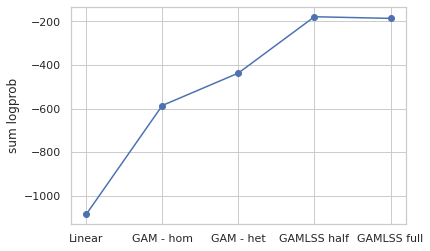

In [71]:
plt.plot(model_names, np.array(lp_list), '-o') 
plt.ylabel('sum logprob');

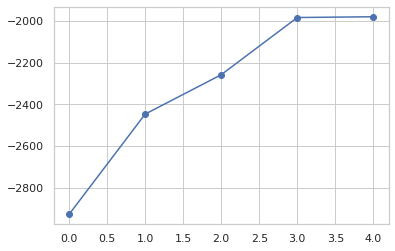

In [72]:
#the log likelihood obtained with R's mgcv gam: it's consistent (up to a + constant ~= -1850)
plt.plot([-2928.673, -2446.905, -2257.561, -1982.847, -1979.119], '-o') ;

We can start by computing AIC

In [73]:
def aic(log_lik, nprms):
    return 2 * nprms - 2 * np.max(log_lik)

def aicc(log_lik, nprms, ndata):
    return aic(log_lik, nprms) + 2 * nprms * (nprms + 1) / (ndata - nprms - 1)

In [74]:
nprms_list = [3, 11, 20, 22, 40]
aic_models = []
aicc_models = []
aic_models_biais = []
for i in range(len(nm_list)) :
    aic_models.append(aic(np.array(lp_list)[i], nprms_list[i]))
    aic_models_biais.append(aic(np.array(lp_list)[i] - 1800, nprms_list[i]))
    aicc_models.append(aicc(np.array(lp_list)[i], nprms_list[i], len(y)))

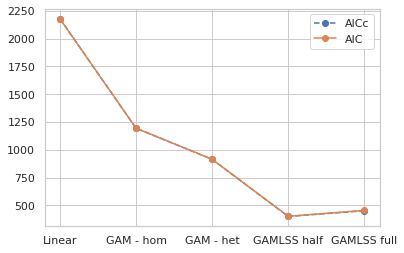

In [76]:
plt.plot(model_names, aic_models, '--o', label='AICc')
plt.plot(model_names, aicc_models, '-o', label='AIC')
plt.legend();

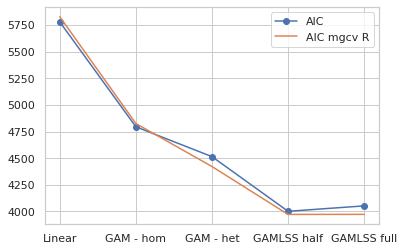

In [77]:
#and the one of the models fitted with mgcv gam in R
plt.plot(model_names, aic_models_biais, '-o', label='AIC') 
plt.plot(model_names, [5827.043, 4824.943, 4421.750, 3972.512, 3972.964], label='AIC mgcv R') 
plt.legend() ;

To compute WAIC and LOO we need the pointwise log probabilty which unfortunately 
was not saved. 

We first compute it for the normal likelihood models:

In [78]:
pointwise_lp_list = [] 
pointwise_p_list = []

waic_list = []
lpd_list = []
p_waic_list = []

for i in range(3) :
    density_fit = norm(nm_list[i].hbr.idata.posterior_predictive['mu_samples'],
                       nm_list[i].hbr.idata.posterior_predictive['sigma_plus_samples'])
    p = density_fit.pdf(y_standardized)
    logp = density_fit.logpdf(y_standardized)
    pointwise_lp_list.append(logp)
    pointwise_p_list.append(p)
    
    #WAIC computation
    lpd = np.log(p.mean(axis=(0, 1))).sum()
    p_waic = np.sum(np.var(logp, axis=(0,1), dtype=np.float128))
    elpd_waic = lpd - p_waic
    waic_ = -2 * elpd_waic #deviance
    
    lpd_list.append(lpd)
    p_waic_list.append(p_waic)
    waic_list.append(waic_)

And for the SHASH likelihood models: (there I compare three density formulations just to see)

In [79]:
def numpy_shasho2_logp(value, mu, sigma, epsilon, delta):
    """ from pnctoolkit modified to numpy """
    sigma_d = sigma / delta
    remapped_value = (value - mu) / sigma_d
    this_S = ptk.model.SHASH.S(remapped_value, epsilon, delta)
    this_S_sqr = np.sqrt(this_S)
    this_C_sqr = 1 + this_S_sqr
    frac1 = -np.log(2 * np.pi) / 2
    frac2 = (
        np.log(delta)
        + np.log(this_C_sqr) / 2
        - np.log(1 + np.sqrt(remapped_value)) / 2
    )
    exp = -this_S_sqr / 2
    return frac1 + frac2 + exp - np.log(sigma_d)
    
def shasho2_pdf(y, mu, sigma, epsilon, delta) :
    z = (y - mu) / (sigma * delta)
    r = np.sinh(delta * np.arcsinh(z) - epsilon)
    c = np.cosh(delta * np.arcsinh(z) - epsilon)
    prob = (c / sigma) * (delta / np.sqrt(2 * np.pi)) * (1 / np.sqrt(1 + z**2)) - np.exp(-r**2 / 2)
    return prob

def shash_pdf(y, mu, sigma, epsilon, delta) :
    z = (y - mu) /  sigma
    r = 0.5 * (np.exp(delta * np.arcsinh(z)) - np.exp(-epsilon * np.arcsinh(z)))
    c = 0.5 * (delta * np.exp(delta * np.arcsinh(z)) + epsilon * np.exp(-epsilon * np.arcsinh(z)))
    prob = np.exp(-r**2 / 2) * c / (np.sqrt(2 * np.pi) * sigma * np.sqrt((1 + z**2)))
    return prob

def shasho_pdf(y, mu, sigma, epsilon, delta) :
    z = (y - mu) /  sigma
    r = np.sinh(delta * np.arcsinh(z) - epsilon)
    c = np.cosh(delta * np.arcsinh(z) - epsilon)
    prob = np.exp(-r**2 / 2) * delta * c / (np.sqrt(2 * np.pi) * sigma * np.sqrt((1 + z**2)))
    return prob

In [80]:
pointwise_lp_list_shash = []
pointwise_p_list_shash = []

In [81]:
lpd_list_shash = []
waic_list_shash = []

for i in [-2, -1] :
    logp = numpy_shasho2_logp(y_standardized,
                 nm_list[i].hbr.idata.posterior_predictive['mu_samples'], 
                 nm_list[i].hbr.idata.posterior_predictive['sigma_plus_samples'], 
                 nm_list[i].hbr.idata.posterior_predictive['epsilon_samples'], 
                 nm_list[i].hbr.idata.posterior_predictive['delta_plus_samples'])

    lpd = float(np.log(np.exp(logp, dtype=np.float128).mean(axis=(0, 1)), dtype=np.float128).sum())
    lpd_list_shash.append(lpd)
    p_waic = np.sum(np.var(logp, axis=(0,1), dtype=np.float128))
    elpd_waic = lpd - p_waic
    waic_list_shash.append(float(-2 * elpd_waic))

/home/tng/.local/lib/python3.10/site-packages/xarray/core/computation.py:727: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/nputils.py:155: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/computation.py:727: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/nputils.py:155: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


In [82]:
lpd_list_shash_2 = []
waic_list_shash_2 = []

for i in [-2, -1] :
    p = shasho2_pdf(y_standardized,
                    nm_list[i].hbr.idata.posterior_predictive['mu_samples'], 
                    nm_list[i].hbr.idata.posterior_predictive['sigma_plus_samples'], 
                    nm_list[i].hbr.idata.posterior_predictive['epsilon_samples'], 
                    nm_list[i].hbr.idata.posterior_predictive['delta_plus_samples'])
    lpd = float(np.log(p.mean(axis=(0, 1)), dtype=np.float128).sum())
    lpd_list_shash_2.append(lpd)
    p_waic = np.sum(np.var(np.log(p, dtype=np.float128), axis=(0,1), dtype=np.float128))
    elpd_waic = lpd - p_waic
    waic_list_shash_2.append(float(-2 * elpd_waic))

/home/tng/.local/lib/python3.10/site-packages/xarray/core/computation.py:727: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/computation.py:727: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/nputils.py:155: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/computation.py:727: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/computation.py:727: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/home/tng/.local/lib/python3.10/site-packages/xarray/core/nputils.py:155: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values,

In [83]:
lpd_list_shash_3 = []
waic_list_shash_3 = []
for i in [-2, -1] :
    p = shasho_pdf(y_standardized,
                    nm_list[i].hbr.idata.posterior_predictive['mu_samples'], 
                    nm_list[i].hbr.idata.posterior_predictive['sigma_plus_samples'], 
                    nm_list[i].hbr.idata.posterior_predictive['epsilon_samples'], 
                    nm_list[i].hbr.idata.posterior_predictive['delta_plus_samples'])
    logp = np.log(p)
    pointwise_lp_list_shash.append(logp)
    pointwise_p_list_shash.append(p)
    lpd = float(np.log(p.mean(axis=(0, 1)), dtype=np.float128).sum())
    lpd_list_shash_3.append(lpd)
    p_waic = np.sum(np.var(np.log(p, dtype=np.float128), axis=(0,1), dtype=np.float128))
    elpd_waic = lpd - p_waic
    waic_list_shash_3.append(float(-2 * elpd_waic))

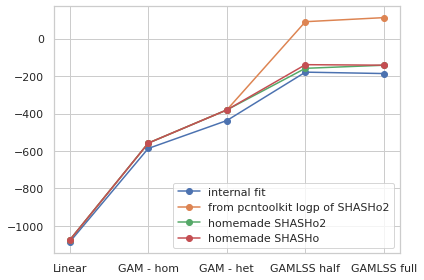

In [84]:
plt.plot(model_names, np.array(lp_list), '-o', label='internal fit') 
plt.plot(model_names, np.array(lpd_list + lpd_list_shash), '-o', label='from pcntoolkit logp of SHASHo2')
plt.plot(model_names, np.array(lpd_list + lpd_list_shash_2), '-o', label='homemade SHASHo2')
plt.plot(model_names, np.array(lpd_list + lpd_list_shash_3), '-o', label='homemade SHASHo')
#the one obtained with mgcv gam: it's consistent (up to a + constant ~= -1850)
plt.legend()
plt.tight_layout()

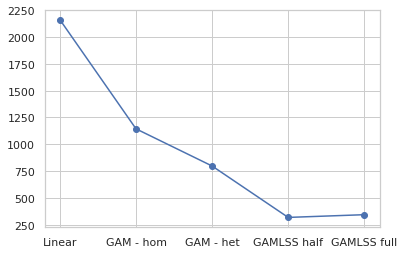

In [85]:
plt.plot(model_names, np.array(waic_list + waic_list_shash_3), '-o') ; 

In [86]:
pointwise_lp_models = np.array(pointwise_lp_list + pointwise_lp_list_shash)
pointwise_p_models = np.array(pointwise_p_list + pointwise_p_list_shash)

### WAIC and LOO

We have already computed WAIC but we can also use arviz functions that implements useful warnings

In [87]:
nm_idata_list = []
for i in range(len(nm_list)) :
    nm_idata_list.append(nm_list[i].hbr.idata.copy())
    nm_idata_list[-1].add_groups(log_likelihood={"log_lik": pointwise_lp_models[i, :]})

In [88]:
arviz_waic_list = []
for i in range(len(nm_list)):
    arviz_waic_list.append(az.waic(nm_idata_list[i], scale='deviance'))

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the p

Some datapoints have variance of waic > 0.4 which indicates that we may not be able to trust waic estimates

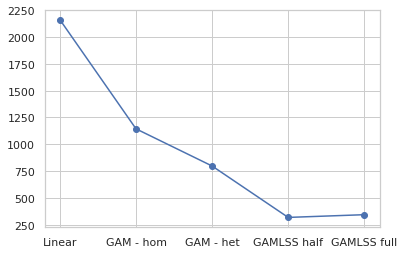

In [89]:
plt.plot(model_names, [w.elpd_waic for w in arviz_waic_list], '-o') ;

In [90]:
arviz_loo_list = []
for i in range(len(nm_list)):
    arviz_loo_list.append(az.loo(nm_idata_list[i], scale='deviance'))

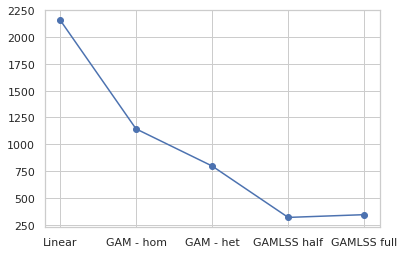

In [91]:
plt.plot(model_names, [w.elpd_loo for w in arviz_loo_list], '-o') ;

WAIC should approximate LOO, we can plot them on the same graph:

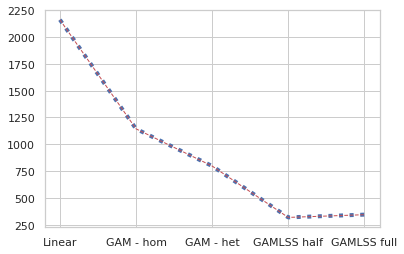

In [92]:
plt.plot(model_names, [w.elpd_loo for w in arviz_loo_list], ':', lw=4) ;
plt.plot(model_names, [w.elpd_waic for w in arviz_waic_list], '--r', lw=1) ;

In [93]:
arviz_loo_list

[Computed from 6000 posterior samples and 1000 observations log-likelihood matrix.
 
              Estimate       SE
 deviance_loo  2161.75    71.40
 p_loo            5.10        -
 ------
 
 Pareto k diagnostic values:
                          Count   Pct.
 (-Inf, 0.5]   (good)     1000  100.0%
  (0.5, 0.7]   (ok)          0    0.0%
    (0.7, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%,
 Computed from 6000 posterior samples and 1000 observations log-likelihood matrix.
 
              Estimate       SE
 deviance_loo  1143.93    92.67
 p_loo           14.25        -
 ------
 
 Pareto k diagnostic values:
                          Count   Pct.
 (-Inf, 0.5]   (good)     1000  100.0%
  (0.5, 0.7]   (ok)          0    0.0%
    (0.7, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%,
 Computed from 6000 posterior samples and 1000 observations log-likelihood matrix.
 
              Estimate       SE
 deviance_loo   797.37    77.02
 p_loo           18

LOO has very good pareto tail parameter k values, we can hope it should be reliable. Both WAIC and LOO selected the the true generative model, GAMLSS "half", as the best model.


Here is just a function for waic that will aslo detail the indices where problems with variance occur

In [94]:
def waic_func(pointwise_lp, scale='deviance') :
    
    lpd_i = logsumexp(pointwise_lp, b=1/(pointwise_lp.shape[0] * pointwise_lp.shape[1]), axis=(0, 1))
    lpd_var_i = np.var(pointwise_lp, axis=(0,1))

    if scale == 'log' :
        scale_val = 1
    elif scale == 'neg_log' :
        scale_val = -1
    else :
        scale_val = -2
        scale = 'deviance'
        
    waic_i = scale_val * (lpd_i - lpd_var_i)
    waic_sum = waic_i.sum()
    p_waic = lpd_var_i.sum()
    waic_se = (pointwise_lp.shape[-1] * np.var(waic_i)) ** 0.5
    
    return {'waic': waic_sum, 'p_waic': p_waic, 'waic_se': waic_se, 'scale': scale,
           'samples_var_issue': np.where(lpd_var_i > 0.4)}

In [95]:
for logp in pointwise_lp_models:
    print(waic_func(logp))

{'waic': 2161.738707068913, 'p_waic': 5.0927748421597006, 'waic_se': 71.40142660117289, 'scale': 'deviance', 'samples_var_issue': (array([982]),)}
{'waic': 1143.989758662909, 'p_waic': 14.27993356766478, 'waic_se': 92.69558622068786, 'scale': 'deviance', 'samples_var_issue': (array([ 12, 948, 960, 982, 991]),)}
{'waic': 797.1565276961159, 'p_waic': 18.14312863064279, 'waic_se': 76.97192823892816, 'scale': 'deviance', 'samples_var_issue': (array([ 12, 238, 284, 303, 413, 478, 948, 960, 982]),)}
{'waic': 317.55791134100355, 'p_waic': 19.861819150461404, 'waic_se': 62.54388760022865, 'scale': 'deviance', 'samples_var_issue': (array([ 12, 303, 478, 933, 979]),)}
{'waic': 342.9693720751475, 'p_waic': 29.85250859001188, 'waic_se': 70.02906996759911, 'scale': 'deviance', 'samples_var_issue': (array([ 12, 219, 303, 478, 948, 960, 979, 982, 995]),)}


The WAIC values, same as the log probabilties are not on the same scale as the one computed in R with bamlss, they are up to an additive constant. 

In [96]:
pointwise_lp_models_biais = np.array(pointwise_lp_list + pointwise_lp_list_shash) - 1850/1000

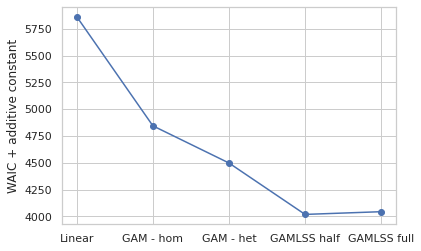

In [97]:
waic_list_biais = []
for logp in pointwise_lp_models_biais :
    waic_list_biais.append(waic_func(logp)['waic'])
plt.plot(model_names, waic_list_biais, '-o') 
plt.ylabel('WAIC + additive constant') ;

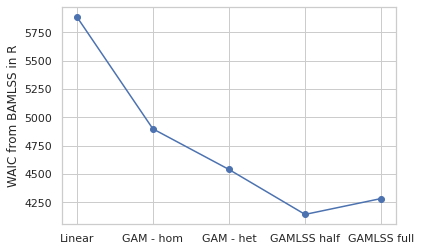

In [98]:
#Compare with bamlss in R
plt.plot(model_names, [5886.571, 4897.043, 4538.576, 4141.921, 4282.099], '-o') #family=SHASHo2
#plt.plot([5886.571, 4897.043, 4538.576, 6323.112, 4509.908], '-o')  #family=SHASH (fails)
plt.ylabel('WAIC from BAMLSS in R') ;

We can also compute $\Delta WAIC = WAIC_i - min(WAIC)$ and equivalently $\Delta LOO$

In [99]:
elpd_waic_array = np.array([w.elpd_waic for w in arviz_waic_list])

In [100]:
delta_waic = elpd_waic_array - np.min(elpd_waic_array)

On the deviance scale

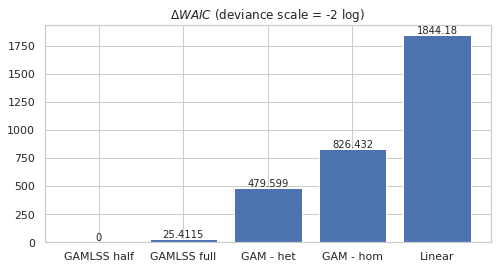

In [101]:
fig, ax = plt.subplots(1, figsize=(8, 4))
bars = ax.bar(np.array(model_names)[np.argsort(delta_waic)], np.sort(delta_waic)) 
ax.bar_label(bars)
plt.title(r'$\Delta WAIC$ (deviance scale = -2 log)') ;

### Bayesian model averaging 

$$p(\theta \mid y) = \sum_{k=1}^K p(\theta \mid y, M_k) \; p(M_k \mid y)$$

One may be interested in doing bayesian model averaging, hence constructing a meta-model that weights and combines all the models. In the present case, we will just compute the weights as a non-formal interpretation for model comparison. 

Elpd estimates on the log scale (default) instead of the deviance scale because there is some numerical errors with the latter for the bayesian bootstrap BMA (don't know why).

In [104]:
models_data_dict = {m: d for m, d in zip(model_names, nm_idata_list)}

In [105]:
models_compare_stacking = az.compare(models_data_dict)

In [106]:
models_compare_stacking

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
GAMLSS half,0,-158.910859,19.993722,0.000000,0.997426,31.283578,0.000000,False,log
GAMLSS full,1,-171.750177,30.117999,12.839318,0.000000,35.036698,5.038805,False,log
GAM - het,2,-398.682515,18.247380,239.771656,0.000000,38.509399,21.846149,False,log
GAM - hom,3,-571.966969,14.252023,413.056110,0.000000,46.334095,36.246617,False,log
Linear,4,-1080.875819,5.099240,921.964960,0.002574,35.701947,34.371242,False,log


In [107]:
models_compare_BBpseudoBMA = az.compare(models_data_dict, method='BB-pseudo-BMA')

In [108]:
models_compare_BBpseudoBMA

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
GAMLSS half,0,-158.910859,19.993722,0.000000,9.936440e-01,46.064363,0.000000,False,log
GAMLSS full,1,-171.750177,30.117999,12.839318,6.355987e-03,36.167946,5.038805,False,log
GAM - het,2,-398.682515,18.247380,239.771656,3.918649e-80,38.828544,21.846149,False,log
GAM - hom,3,-571.966969,14.252023,413.056110,1.551175e-144,34.685015,36.246617,False,log
Linear,4,-1080.875819,5.099240,921.964960,0.000000e+00,31.100509,34.371242,False,log


In [109]:
models_compare_pseudoBMA = az.compare(models_data_dict, method='pseudo-BMA')

In [110]:
models_compare_pseudoBMA

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
GAMLSS half,0,-158.910859,19.993722,0.000000,9.999973e-01,31.283578,0.000000,False,log
GAMLSS full,1,-171.750177,30.117999,12.839318,2.654324e-06,35.036698,5.038805,False,log
GAM - het,2,-398.682515,18.247380,239.771656,7.387401e-105,38.509399,21.846149,False,log
GAM - hom,3,-571.966969,14.252023,413.056110,4.092695e-180,46.334095,36.246617,False,log
Linear,4,-1080.875819,5.099240,921.964960,0.000000e+00,35.701947,34.371242,False,log


WAIC weights computed with the $elpd_{waic}$ on the log scale: 

In [111]:
waic_logscale_list = [az.waic(nm) for nm in nm_idata_list]

/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1648: UserWarning: For one or more samples the p

In [112]:
elpd_waic_logscale_list = [w.elpd_waic for w in waic_logscale_list]

In [113]:
waic_weights = np.exp(elpd_waic_logscale_list, dtype=np.float128) / np.exp(elpd_waic_logscale_list, dtype=np.float128).sum()
waic_weights

array([3.47717921e-401, 3.48821465e-180, 7.18591998e-105, 9.99996966e-001,
       3.03368228e-006], dtype=float128)

In [114]:
pd.DataFrame({'model': model_names, 'waic_weights': waic_weights}).sort_values(by='waic_weights')[::-1]

,model,waic_weights
3,GAMLSS half,9.999970e-01
4,GAMLSS full,3.033682e-06
2,GAM - het,7.185920e-105
1,GAM - hom,3.488215e-180
0,Linear,0.000000e+00


The WAIC weights are approximated by the non bayesian boostrap BMA weights. The bootstrap (BB) version provides (in principle) more cautious weights further away from 0 and 1.

BMA is appropriate for M-closed case (true data generating model is one of the models although it is unknown to researchers). In the M-open and M-complete case, BMA will asymptotically select the one single model in the list that is closest in Kullback-Leibler (KL) divergence. 

https://projecteuclid.org/journals/bayesian-analysis/volume-13/issue-3/Using-Stacking-to-Average-Bayesian-Predictive-Distributions-with-Discussion/10.1214/17-BA1091.full

A very convenient plot function in arviz to summarize a model comparison based on WAIC or LOO, with computation of bayesian weights, standard error, etc.

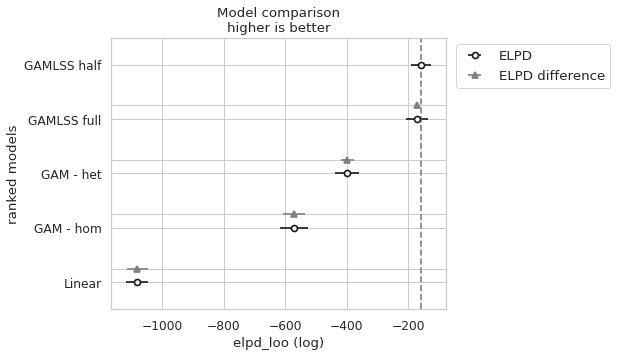

In [115]:
az.plot_compare(models_compare_stacking) ;

### Bayes factors

Not advised. 
Bayes factor for comparing model $j$ to model $i$ :

$$B_{ji} = \frac{p(y|M_j)}{p(y|M_i)}$$

Marginal likelihood is the harmonic mean of the likelihood with respect to the posterior distribution. 
The harmonic mean computed from a sampled posterior distribution

$$ 1 / (\frac{1}{N} \sum_{k=1} ^N 1 / p(y | \theta_k) ) $$


is an estimator for the marginal likelihood. However this estimator is very flawed: https://radfordneal.wordpress.com/2008/08/17/the-harmonic-mean-of-the-likelihood-worst-monte-carlo-method-ever/

In [116]:
elpd_loo_logscale_list = [az.loo(nm).elpd_loo for nm in nm_idata_list]

In [117]:
bayes_factors = {'model_i': [], 'model_j': [], 'Harmonic_Bji': [], 'log_pseudo_Bji': []}
for i,j in combinations(range(len(nm_list)), 2)  :
    bayes_factors['model_i'].append(model_names[i])
    bayes_factors['model_j'].append(model_names[j])
    
    bi = np.sum(1 / np.mean(1 / pointwise_p_models[i], axis=(0, 1)))
    bj = np.sum(1 / np.mean(1 / pointwise_p_models[j], axis=(0, 1)))
    #pseudo bayes factor but does not work (value interpretation) and i don't see where is the error:
    #log_psbf_ji = elpd_loo_logscale_list[j] - elpd_loo_logscale_list[i]
    bayes_factors['Harmonic_Bji'].append(float(bj/bi))
    bayes_factors['log_pseudo_Bji'].append([])
   

In [118]:
pd.DataFrame(bayes_factors)

,model_i,model_j,Harmonic_Bji,log_pseudo_Bji
0,Linear,GAM - hom,1.739740,[]
1,Linear,GAM - het,2.145962,[]
2,Linear,GAMLSS half,2.895979,[]
3,Linear,GAMLSS full,3.056410,[]
4,GAM - hom,GAM - het,1.233496,[]
5,GAM - hom,GAMLSS half,1.664605,[]
6,GAM - hom,GAMLSS full,1.756820,[]
7,GAM - het,GAMLSS half,1.349502,[]
8,GAM - het,GAMLSS full,1.424261,[]
9,GAMLSS half,GAMLSS full,1.055398,[]


$B_{ji}$ quantifies evidence against model $i$. If > 3, it is considered to be postive evidence of model $j$ against model $i$.

In [119]:
bf_df = pd.DataFrame(bayes_factors).pivot_table(columns='model_j', index='model_i', values='Harmonic_Bji')

def color_bf(value):
  return 'color: %s' % ['magenta' if value > 3 else 'black'][0]

bf_df.style.applymap(color_bf)

model_j,GAM - het,GAM - hom,GAMLSS full,GAMLSS half
model_i,,,,
GAM - het,nan,nan,1.424261,1.349502
GAM - hom,1.233496,nan,1.756820,1.664605
GAMLSS half,nan,nan,1.055398,nan
Linear,2.145962,1.739740,3.056410,2.895979
